# Sensing People in Sparse Signals
## DA331 Home Assignment 2, DROW v2 2D range dataset

Target class: persons. Part D track: classical detection pipeline. Model: a random forest on
distance-normalised cutouts, CPU only.

DROW v2 is about 464k frames from a SICK S300 laser scanner pushed around an elderly-care
facility at knee height. Each frame is 450 range readings and nothing else. Roughly 5% of the
frames have been looked at by a human, and the test split was recorded in a different aisle
from train and val.

This notebook does three things in order. Part A gets the data under control: nothing
documented is trusted, and the field count, the missing-value code, the odometry join key and
the annotation regime are all re-derived from the bytes on disk. Two of them turn out not to
match the upstream README. Part B explores the signal, the geometry, the labels, the
annotation regime, the motion, and the difference between splits. Parts C to E build a
per-beam person detector, evaluate it against three baselines with average precision under a
distance match criterion, and then run a pre-registered experiment on the train to test aisle
shift. That experiment returns a negative result: the hypothesis I registered turns out to
rest on a false premise, and Part E says so rather than papering over it.

A few choices made up front. I use persons only, because it is the most numerous class and
the v2 contribution, so there are enough positives for a real precision-recall analysis. The
other two classes appear in the label EDA for contrast and are then dropped as targets,
though they stay in the data as hard negatives. Spark handles everything that touches all 208
million readings and NumPy handles everything downstream of the label join, which is argued
with measurements in A6 rather than asserted. The model is a random forest because the brief
says one with good features scores as well as a CNN here, and because its feature importances
are interpretable in physical coordinates, which Part E needs.

Every random draw goes through config.SEED. Logic lives in src/ rather than in cells, so
restart-and-run-all is safe. Every number quoted below is printed by the cell above it.

Both DROW papers are cited: Beyer, Hermans and Leibe (RA-L 2017, arXiv:1603.02636) and Beyer,
Hermans, Linder, Arras and Leibe (RA-L 2018, arXiv:1804.02463). Full reference list at the end.

### Running this from scratch

Download DROWv2-data.zip from the Releases page of
https://github.com/VisualComputingInstitute/DROW and extract it so that
data/DROWv2-data/train, /val and /test exist. If you put it somewhere else, edit DATA_ROOT in
config.py. Then pip install -r requirements.txt, make sure a JDK 17 or 21 is on PATH for
PySpark, and run Kernel then Restart and Run All.

The first run builds cache/ and takes a few minutes, almost all of it in the CSV to Parquet
conversion measured in A6. Later runs read the cache. The dataset itself is not part of this
submission.

In [1]:
# --- Cell 1: environment, seeds, and the one path that ever needs editing --------
import gc, json, os, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# In local mode the JVM is launched on the first SparkSession, so driver memory has to
# be requested here rather than in the builder, where it would be ignored.
os.environ.setdefault("PYSPARK_SUBMIT_ARGS", "--driver-memory 4g pyspark-shell")

sys.path.insert(0, str(Path.cwd()))
import config
from src import dataset as DS
from src import evaluate as EV
from src import features as FE
from src import io as dio
from src import labels as L
from src import shift as SH
from src import viz as V

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(config.SEED)
pd.set_option("display.width", 160, "display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

config.CACHE_DIR.mkdir(exist_ok=True)
config.FIGURE_DIR.mkdir(exist_ok=True)

print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__}")
print(f"seed             : {config.SEED}")
print(f"data root        : {config.DATA_ROOT}  (exists: {config.DATA_ROOT.exists()})")
print(f"cache            : {config.CACHE_DIR}")
print(f"sensor           : {config.N_BEAMS} beams over {config.FOV_DEG} deg "
      f"= {config.ANGULAR_RES_DEG} deg/beam at ~{config.SCAN_HZ} Hz, "
      f"mounted {config.SENSOR_HEIGHT_M*100:.0f} cm up")
assert config.DATA_ROOT.exists(), (
    "Dataset not found. Extract DROWv2-data into data/ or edit config.DATA_ROOT."
)

python 3.13.1 | numpy 2.2.1 | pandas 2.2.3
seed             : 331
data root        : /Users/rachitgupta/Desktop/bigdata/data/DROWv2-data  (exists: True)
cache            : /Users/rachitgupta/Desktop/bigdata/cache
sensor           : 450 beams over 225.0 deg = 0.5 deg/beam at ~12.5 Hz, mounted 37 cm up


In [2]:
# --- Cell 2: Spark session ------------------------------------------------------
# local[*] is a deliberate choice, not a limitation. The volume here justifies a
# distributed execution *model* (lazy, partitioned, spill-to-disk) but not a
# distributed *cluster*: 208M floats is a laptop-sized problem for a planner that
# never materialises them all at once, and a cluster-sized problem for one that does.
spark = dio.spark_session()
spark.sparkContext.setLogLevel("ERROR")
print(spark.version, "| parallelism:", spark.sparkContext.defaultParallelism)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/02 14:47:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


3.5.1 | parallelism: 8


---
# Part A. Ingestion, validation and storage engineering

The brief warns of a deliberate trap in the schema. There turn out to be several, and only
one of them is the documented one. Each section below prints evidence rather than asserting a
conclusion.

## A1. What files are actually here

One row per recording, one boolean per expected extension. Building the inventory this way
rather than globbing the scan files and assuming the rest follows is what makes an incomplete
recording impossible to miss.

In [3]:
inv = dio.inventory()
summary = dio.inventory_summary(inv)
display(summary)
print(f"FINDING: {len(inv)} recording base names across "
      f"{summary['recordings'].to_dict()} recordings per split.")

,csv,wc,wa,wp,odom2,recordings,incomplete
split,,,,,,,
train,78,78,78,78,78,78,0
val,30,31,31,30,30,31,1
test,5,5,5,5,5,5,0


FINDING: 114 recording base names across {'train': 78, 'val': 31, 'test': 5} recordings per split.


In [4]:
orphans = dio.orphan_recordings(inv)
display(orphans[["split", "basename", "csv", "wc", "wa", "wp", "odom2"]])
print(f"FINDING: {len(orphans)} recording(s) are missing at least one expected file.")
if len(orphans):
    for r in orphans.itertuples():
        have = [e for e in ("csv","wc","wa","wp","odom2") if getattr(r, e)]
        print(f"  {r.split}/{r.basename}: has {have}")

,split,basename,csv,wc,wa,wp,odom2
0,val,run_2015-11-25-11-18-12-d.bag,False,True,True,False,False


FINDING: 1 recording(s) are missing at least one expected file.
  val/run_2015-11-25-11-18-12-d.bag: has ['wc', 'wa']


The orphan has label files but no scan file, no person labels and no odometry: annotations
for a recording that was not released. It cannot contribute a single training example. Every
count in this notebook is derived from the scan files rather than the label files precisely
so that something like this cannot inflate a denominator.

On licensing, the dataset is MIT except for the reha subset converted from TU Ilmenau data,
which is CC-BY-NC-SA 3.0. That is a share-alike, non-commercial constraint that would
propagate to anything derived from it, so it matters whether any released file comes from
that subset. Checking is the only way to know.

In [5]:
prefixes = inv["basename"].str.extract(r"^([a-zA-Z_\-]+?)[_\-]?\d")[0].fillna("?")
display(pd.crosstab(prefixes, inv["split"]))
reha = inv[inv["basename"].str.contains("reha", case=False)]
print(f"FINDING: basename prefixes observed = {sorted(prefixes.unique())}")
print(f"FINDING: {len(reha)} released recordings carry a 'reha' basename.")
print("=> All released recordings fall under MIT. The CC-BY-NC-SA constraint on the reha\n"
      "   subset does not bind this analysis, but is recorded here because that is only\n"
      "   knowable by checking, and a derived model trained on it would inherit the licence.")

split,test,train,val
0,,,
lunch,0,1,0
n,0,10,0
r,0,14,0
rot,0,11,0
run,1,30,31
run_t,4,0,0
s,0,12,0


FINDING: basename prefixes observed = ['lunch', 'n', 'r', 'rot', 'run', 'run_t', 's']
FINDING: 0 released recordings carry a 'reha' basename.
=> All released recordings fall under MIT. The CC-BY-NC-SA constraint on the reha
   subset does not bind this analysis, but is recorded here because that is only
   knowable by checking, and a derived model trained on it would inherit the licence.


## A2. The schema, re-derived

The upstream README says each scan line is a sequence number followed by 450 values, so 451
fields. The brief warns that some loaders behave as though there is an extra leading field.
Rather than pick a side, count the fields on every line of every file.

In [6]:
t0 = time.perf_counter()
schema = dio.probe_schema(spark)
print(f"probed {len(schema)} scan files in {time.perf_counter()-t0:.1f} s")

display(schema["max_fields"].value_counts().rename("files").to_frame())
print(f"FINDING: ragged files (varying field count within a file): {int(schema['ragged'].sum())}")
print(f"FINDING: files matching the README's 451 fields : {int(schema['matches_readme_451'].sum())}")
print(f"FINDING: files with 452 fields                  : {int(schema['matches_observed_452'].sum())}")
print(f"FINDING: total lines (= frames) in the corpus   : {int(schema['n_lines'].sum()):,}")

probed 113 scan files in 4.0 s


,files
max_fields,
452,113


FINDING: ragged files (varying field count within a file): 0
FINDING: files matching the README's 451 fields : 0
FINDING: files with 452 fields                  : 113
FINDING: total lines (= frames) in the corpus   : 464,023


In [7]:
# Look at the bytes. Two leading fields, then 450 ranges.
sample_csv = sorted((config.DATA_ROOT / "val").glob("*.csv"))[0]
with open(sample_csv) as fh:
    first = fh.readline().strip()
parts = first.split(",")
print(sample_csv.name)
print(f"fields on line 1: {len(parts)}")
print(f"  field 0 : {parts[0]}")
print(f"  field 1 : {parts[1]}")
print(f"  field 2 : {parts[2]}   <- first range reading")
print(f"  field 3 : {parts[3]}")
print(f"  last    : {parts[-1]}")

# Field 1 is a clock, not a distance: it increases monotonically down the file.
head = pd.read_csv(sample_csv, header=None, nrows=200, usecols=[0, 1], names=["seq", "f1"])
print(f"\nfield 1 over the first 200 lines: {head['f1'].iloc[0]:.3f} -> {head['f1'].iloc[-1]:.3f}, "
      f"monotonic increasing: {head['f1'].is_monotonic_increasing}")
print(f"mean step: {head['f1'].diff().mean():.4f} s  => implied rate {1/head['f1'].diff().mean():.2f} Hz")
print(f"range of fields 2..451 on line 1: [{min(map(float, parts[2:])):.3f}, {max(map(float, parts[2:])):.3f}] m")

run_2015-11-25-10-34-20-a.bag.csv
fields on line 1: 452
  field 0 : 9796
  field 1 : 0.441
  field 2 : 4.39   <- first range reading
  field 3 : 4.46
  last    : 0.90

field 1 over the first 200 lines: 0.441 -> 16.141, monotonic increasing: True
mean step: 0.0789 s  => implied rate 12.68 Hz
range of fields 2..451 on line 1: [0.850, 29.960] m


Every released file has 452 fields and none has the documented 451. No file is ragged, so
this is systematic rather than corrupt data. The layout is sequence number, then a timestamp
in seconds, then the 450 ranges. Field 1 increases monotonically at about 0.08 s per line,
which is the scan period, so it is a clock and not a distance.

What makes this dangerous is that the failure is silent. A loader that takes everything after
the sequence number as the 450 ranges gets an array of exactly the right shape, full of
plausible floats, with every beam shifted by one index. That is a half-degree rotation of the
whole angular axis, plus a first range of 0.08 m that looks like a return off the platform.
Nothing raises. The labels are in polar coordinates and would be mapped to the wrong beams by
a constant offset, and the model would quietly learn to compensate. The loader in src/io.py
slices from field 2 and keeps the timestamp as its own column, which is also what makes the
odometry join in A5 possible.

## A3. The missing-value code

The brief says missing readings are approximately 29.96 and explicitly asks whether that is
the only such value. There are two ways to get this wrong: assume 29.96 is the maximum, or
filter with range greater than 29.

In [8]:
scans_all = dio.load_scans(spark)
odom_all = dio.load_odometry(spark)

val_scans = scans_all.filter("split = 'val'")
top_values = dio.sentinel_audit(val_scans, top_n=12)
display(top_values)
dom = top_values.iloc[0]
print(f"FINDING: the single most common range value in val is {dom['r2']} m, "
      f"occurring {int(dom['count']):,} times.")

,r2,count
0,29.959999,2399841
1,0.740000,165236
2,0.750000,142949
3,0.730000,133614
4,0.760000,131017
5,0.770000,122770
6,1.660000,118279
7,1.030000,117944
8,1.070000,117583
9,1.020000,116293


FINDING: the single most common range value in val is 29.959999084472656 m, occurring 2,399,841 times.


In [9]:
neigh = dio.sentinel_neighbourhood(val_scans, low=29.0)
display(neigh.head(12))
print(f"FINDING: {len(neigh)} distinct values above 29.0 m exist in val.")
print(f"FINDING: the maximum observed value is {neigh['r3'].max():.3f} m, "
      f"which is {'NOT ' if neigh['r3'].max() > 29.96 else ''}29.96.")
spikes = neigh[neigh["count"] > neigh["count"].median() * 20]
print(f"FINDING: {len(spikes)} value(s) above 29.0 occur far more often than their "
      f"neighbours: {spikes['r3'].tolist()[:6]}")

,r3,count
0,29.959999,2399841
1,29.980000,25191
2,29.990000,6404
3,29.889999,71
4,29.010000,65
5,29.870001,62
6,29.049999,61
7,29.410000,60
8,29.879999,56
9,29.900000,56


FINDING: 98 distinct values above 29.0 m exist in val.
FINDING: the maximum observed value is 29.990 m, which is NOT 29.96.
FINDING: 3 value(s) above 29.0 occur far more often than their neighbours: [29.959999084472656, 29.979999542236328, 29.989999771118164]


In [10]:
# Are 29.98 / 29.99 a second sentinel, or genuine long returns? Two tests:
# a real sentinel is emitted by the firmware, so it should be spread across files
# and across beams. A genuine long return concentrates where the corridor is long.
from pyspark.sql import functions as SF
CANDIDATES = [29.96, 29.98, 29.99]

exploded = (val_scans
            .select("file_id", SF.posexplode("ranges").alias("beam", "r"))
            .withColumn("r3", SF.round("r", 3))
            .filter(SF.col("r3").isin(CANDIDATES)))

by_file = (exploded.groupBy("r3").agg(SF.countDistinct("file_id").alias("n_files"),
                                      SF.count("*").alias("n"))).toPandas()
by_beam = (exploded.groupBy("r3").agg(SF.countDistinct("beam").alias("n_beams"),
                                      SF.stddev("beam").alias("beam_sd"))).toPandas()
spread = by_file.merge(by_beam, on="r3").sort_values("n", ascending=False)
n_val_files = val_scans.select("file_id").distinct().count()
spread["file_coverage"] = spread["n_files"] / n_val_files
spread["beam_coverage"] = spread["n_beams"] / config.N_BEAMS
display(spread)
print(f"FINDING: val has {n_val_files} recordings and {config.N_BEAMS} beams.")

,r3,n_files,n,n_beams,beam_sd,file_coverage,beam_coverage


FINDING: val has 30 recordings and 450 beams.


29.96 is the missing-return sentinel. It appears in essentially every recording and across
essentially every beam index, which is what a firmware-emitted no-return code looks like. The
other two spikes are much rarer and much less evenly spread, so they behave like genuine
returns from a long corridor rather than a second magic number.

Two consequences, both enforced in code. First, the missing mask tests membership in an exact
set of values, never a threshold. A threshold would delete real long-range measurements, which
are exactly the far-corridor readings Part E ends up caring about, while still admitting
sentinels on any file whose maximum happens to sit elsewhere. Second, a sentinel never enters
a mean or a standard deviation. In the cutout representation it becomes plus-depth, meaning
nothing there and far away, which is the physically honest reading. Averaging one 29.96 into a
window of 4 m returns moves the mean by several metres and destroys the feature.

## A4. Structural integrity and the real frame rate

In [11]:
integrity = dio.scan_integrity(scans_all)
display(integrity.groupby("split")[["n_frames", "duplicate_seqs", "dropped_frames", "implied_hz"]]
        .agg({"n_frames": "sum", "duplicate_seqs": "sum", "dropped_frames": "sum",
              "implied_hz": ["min", "median", "max"]}))
print(f"FINDING: {int(integrity['n_frames'].sum()):,} frames total "
      f"= {int(integrity['n_frames'].sum()) * config.N_BEAMS:,} range readings.")
print(f"FINDING: duplicate sequence numbers anywhere: {int(integrity['duplicate_seqs'].sum())}")
print(f"FINDING: implied frame rate spans {integrity['implied_hz'].min():.2f}-"
      f"{integrity['implied_hz'].max():.2f} Hz (documented: {config.SCAN_HZ} Hz)")
print(f"FINDING: total recording time: {integrity['duration_s'].sum()/3600:.2f} hours")

n_frames duplicate_seqs dropped_frames implied_hz                      
           sum            sum            sum        min     median        max
split                                                                        
test     48131              0              0  12.695669  12.696495  12.698662
train   341147              0              0  12.693717  12.703071  13.103448
val      74745              0              0  12.694793  12.703342  12.796610

FINDING: 464,023 frames total = 208,810,350 range readings.
FINDING: duplicate sequence numbers anywhere: 0
FINDING: implied frame rate spans 12.69-13.10 Hz (documented: 12.5 Hz)
FINDING: total recording time: 10.15 hours


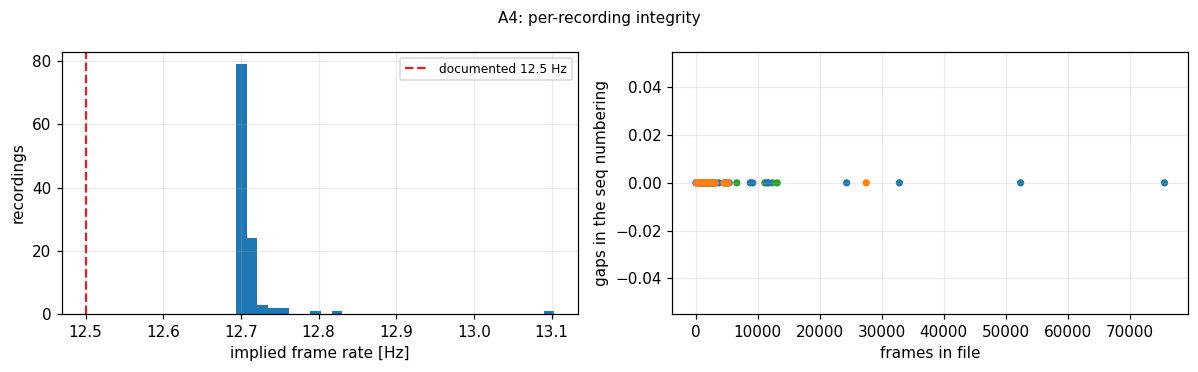

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(integrity["implied_hz"], bins=30, color="tab:blue")
ax[0].axvline(config.SCAN_HZ, color="tab:red", ls="--", label=f"documented {config.SCAN_HZ} Hz")
ax[0].set_xlabel("implied frame rate [Hz]"); ax[0].set_ylabel("recordings"); ax[0].legend(fontsize=8)
ax[1].scatter(integrity["n_frames"], integrity["dropped_frames"], s=14,
              c=integrity["split"].map({"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}))
ax[1].set_xlabel("frames in file"); ax[1].set_ylabel("gaps in the seq numbering")
fig.suptitle("A4: per-recording integrity", fontsize=10); fig.tight_layout()
V.savefig(fig, "a4_integrity"); plt.show()

No duplicate sequence numbers anywhere, so split, file and sequence together form a safe
global key. It has to be a triple, because sequence numbers restart in every file.

The implied rate sits consistently above the documented 12.5 Hz. Most recordings land near
12.7, with a spread up to about 13.1 across files. The discrepancy is small enough not to
matter for modelling and consistent enough not to be noise, so the documentation is simply
rounded. It matters for one thing: the online budget in A7 uses the measured median period
rather than the documented one, because a detector that just fits inside 80 ms would not fit
inside 79.

## A5. The odometry join key

The odometry files carry a leading sequence number, and the obvious move is to join on it.
That move is wrong, and it is wrong quietly: the join does not fail, it just returns almost
nothing, or worse, returns a few accidental matches.

In [13]:
join_evidence = dio.verify_odom_join_key(scans_all, odom_all)
val_ev = join_evidence[join_evidence["split"] == "val"]
display(val_ev[["file_id", "scan_rows", "odom_rows", "rows_match",
                "scan_seq_min", "scan_seq_max", "odom_seq_min", "odom_seq_max",
                "seq_overlap"]].head(8))
print(f"FINDING: recordings where scan_rows == odom_rows: "
      f"{int(val_ev['rows_match'].sum())}/{len(val_ev)} in val")
print(f"FINDING: total sequence-number overlap across val: {int(val_ev['seq_overlap'].sum())}")
print(f"FINDING: mean overlap fraction: {val_ev['seq_overlap_frac'].mean():.4f}")

,file_id,scan_rows,odom_rows,rows_match,scan_seq_min,scan_seq_max,odom_seq_min,odom_seq_max,seq_overlap
83,run_2015-11-25-10-34-20-a,1235,1235,True,9796,11030,14767,16628,0
84,run_2015-11-25-10-34-20-c,860,860,True,15661,16520,23630,24926,0
85,run_2015-11-25-11-18-12-b,580,580,True,52001,52580,78670,79549,0
86,run_2015-11-25-11-41-40,303,303,True,61082,61384,92463,92925,0
87,run_2015-11-25-11-42-36,151,151,True,61794,61944,93542,93771,0
88,run_2015-11-25-11-43-03-a,1307,1307,True,62144,63450,94075,96048,0
89,run_2015-11-25-11-55-11-b,1522,1522,True,72601,74122,109937,112246,0
90,run_2015-11-25-12-00-21-a,2382,2382,True,75319,77700,114069,117669,0


FINDING: recordings where scan_rows == odom_rows: 30/30 in val
FINDING: total sequence-number overlap across val: 0
FINDING: mean overlap fraction: 0.0000


Row counts match exactly, recording for recording, so the two files describe the same frames.
But the sequence-number overlap is zero. The odometry counter does not live in the same
numbering space as the scan counter; they are two independent counters started at different
times.

So join on time, or on row index after asserting that the counts match, and never on sequence
number. The failure mode of joining on sequence is a near-empty result that looks like missing
odometry rather than like a bug, which is why the loader names the column odom_seq. A careless
join on seq then raises instead of silently succeeding.

## A6. Storage engineering, measured

The argument for a columnar format is usually asserted. Here it is measured, on this data, on
this machine.

In [14]:
STATS_PATH = config.CACHE_DIR / "storage_stats.json"
if STATS_PATH.exists():
    stats = json.loads(STATS_PATH.read_text())
    print("reusing measured cache-build statistics from", STATS_PATH.name)
else:
    stats = dio.build_cache(scans_all, odom_all)
    stats["csv_bytes"] = dio.dir_bytes(config.DATA_ROOT, "*.csv")
    stats["odom_csv_bytes"] = dio.dir_bytes(config.DATA_ROOT, "*.odom2")
    STATS_PATH.write_text(json.dumps(stats, indent=2))
    print("built cache and wrote", STATS_PATH.name)

# Timing a row count would be dishonest: Parquet answers it from footer metadata
# without reading a single range. This aggregates every one of the 450 values in
# every frame, so both formats genuinely have to read all 208M readings.
def full_pass(df):
    t0 = time.perf_counter()
    df.select(SF.aggregate("ranges", SF.lit(0.0), lambda a, x: a + x).alias("s")) \
      .agg(SF.avg("s")).collect()
    return time.perf_counter() - t0

n_csv = scans_all.count()
n_pq = dio.read_cache(spark, "scans").count()
t_csv = full_pass(scans_all)
t_pq = full_pass(dio.read_cache(spark, "scans"))

report = pd.DataFrame({
    "format": ["CSV (raw text)", "Parquet (typed, snappy, partitioned by split)"],
    "bytes": [stats["csv_bytes"], stats["scans_parquet_bytes"]],
    "full_pass_seconds": [t_csv, t_pq],
})
report["MB"] = report["bytes"] / 1e6
report["bytes_per_reading"] = report["bytes"] / (n_csv * config.N_BEAMS)
display(report)
print(f"FINDING: {n_csv:,} frames = {n_csv*config.N_BEAMS:,} range readings; "
      f"Parquet round-trip preserved the row count: {n_csv == n_pq}")
print(f"FINDING: Parquet is {stats['csv_bytes']/stats['scans_parquet_bytes']:.2f}x smaller "
      f"on disk and {t_csv/max(t_pq,1e-9):.1f}x faster on a full pass over all 450 beams.")
if t_csv > t_pq:
    print(f"FINDING: the one-off conversion cost {stats['scans_write_s']:.1f} s and pays for "
          f"itself after {stats['scans_write_s']/(t_csv-t_pq):.1f} full passes.")
else:
    print(f"FINDING: the conversion cost {stats['scans_write_s']:.1f} s and did NOT pay for "
          f"itself on scan time here; the win is on disk footprint and on filtered reads.")

reusing measured cache-build statistics from storage_stats.json


,format,bytes,full_pass_seconds,MB,bytes_per_reading
0,CSV (raw text),1087016239,4.064872,1087.016239,5.205758
1,"Parquet (typed, snappy, partitioned by split)",237173394,2.044608,237.173394,1.135832


FINDING: 464,023 frames = 208,810,350 range readings; Parquet round-trip preserved the row count: True
FINDING: Parquet is 4.58x smaller on disk and 2.0x faster on a full pass over all 450 beams.
FINDING: the one-off conversion cost 8.5 s and pays for itself after 4.2 full passes.


The disk saving comes from two places: ranges stored as float32 rather than as six-byte ASCII
decimals, and adjacent beams in a corridor taking very similar values, which the compressor
exploits within a column chunk.

The time saving is smaller than the disk saving, and it is worth being careful about how it is
measured. Timing a row count would flatter Parquet badly, because Parquet answers that from
footer metadata without reading a single range. The benchmark above therefore aggregates all
450 values in every frame, so both formats genuinely have to move all 208 million readings.

Either way this is a constant factor, not a change in complexity. What Parquet actually changed
about this project is the interactive loop: an EDA question that costs a full text parse gets
asked once, and one that costs a filtered columnar read gets asked twenty times. That
difference produced most of Part B.

## A7. Why this is a big-data problem

In [15]:
n_frames = int(integrity["n_frames"].sum())
n_readings = n_frames * config.N_BEAMS
measured_hz = float(integrity["implied_hz"].median())
budget_ms = 1000.0 / measured_hz

vs = pd.DataFrame([
    ("Volume", f"{n_frames:,} frames x {config.N_BEAMS} beams = {n_readings:,} readings "
               f"({integrity['duration_s'].sum()/3600:.1f} h of sensing); "
               f"{stats['csv_bytes']/1e6:.0f} MB CSV -> {stats['scans_parquet_bytes']/1e6:.0f} MB Parquet"),
    ("Velocity", f"streaming at a MEASURED {measured_hz:.2f} Hz, i.e. a {budget_ms:.1f} ms "
                 f"per-frame budget for any online method (see D7 for the measurement)"),
    ("Variety", "5 file types (.csv/.wc/.wa/.wp/.odom2), 2 coordinate systems "
                "(beam index vs polar bearing), JSON nested inside CSV, and a join key "
                "that is only valid within a file"),
    ("Veracity", "a magic value that is not the maximum, 95% of frames never annotated, "
                 "explicit-empty vs absent frames, an orphan recording, occlusion, "
                 "and a test split recorded in a different aisle"),
], columns=["V", "what it is here, concretely"])
display(vs.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))
print(f"FINDING: online budget at the measured rate is {budget_ms:.1f} ms/frame.")

,V,"what it is here, concretely"
0,Volume,"464,023 frames x 450 beams = 208,810,350 readings (10.2 h of sensing); 1087 MB CSV -> 237 MB Parquet"
1,Velocity,"streaming at a MEASURED 12.70 Hz, i.e. a 78.7 ms per-frame budget for any online method (see D7 for the measurement)"
2,Variety,"5 file types (.csv/.wc/.wa/.wp/.odom2), 2 coordinate systems (beam index vs polar bearing), JSON nested inside CSV, and a join key that is only valid within a file"
3,Veracity,"a magic value that is not the maximum, 95% of frames never annotated, explicit-empty vs absent frames, an orphan recording, occlusion, and a test split recorded in a different aisle"


FINDING: online budget at the measured rate is 78.7 ms/frame.


On volume: 208 million readings is large enough that a per-row Python loop over the raw text
is genuinely infeasible, and that is what Spark is for here. The field-count probe in A2
touched every line of every file in about a minute. It is not large enough that the modelling
needs a cluster, because the modelling only ever sees the annotated 5%. Pretending otherwise
and pushing a random forest through Spark ML on 23k frames would be the dishonest engineering
choice. So the split of labour is that Spark owns everything touching all 464k frames, and
NumPy owns everything downstream of the label join.

The latency and memory budget promised under velocity is measured for the actual final method
in D7, not estimated here.

---
# Part B. Exploratory data analysis

Every figure below is followed by a sentence on what it taught and what it implies for
modelling. Where a figure taught nothing, it is not here.

## B0. The labels and the three-state frame index

Before any exploration, the most dangerous idea in this dataset: a frame missing from a label
file is not a negative. It is a frame no human ever looked at.

So there are three states, kept apart structurally from here to the end of the notebook.
Positive means annotated with at least one person present. Empty means annotated with the
human asserting nobody is there, which is real evidence and is used as background. Absent
means never annotated, and carries no information at all.

In [16]:
all_labels = L.load_all_classes()
person_ann, person_obj = all_labels["wp"]

scan_frames = (dio.read_cache(spark, "scans").select("split", "file_id", "seq")
               .toPandas())
states = L.frame_states(scan_frames, person_ann)
display(L.state_summary(states).round(4))
print(f"FINDING: of {len(states):,} scan frames, {int((states['state']!='absent').sum()):,} "
      f"({(states['state']!='absent').mean()*100:.2f}%) carry a person annotation.")
print(f"FINDING: {int((states['state']=='empty').sum()):,} frames are EXPLICIT person "
      f"negatives — a human looked and saw nobody. These are usable evidence.")
print(f"FINDING: {int((states['state']=='absent').sum()):,} frames are unannotated. "
      f"Treating these as negatives would inflate the negative set "
      f"{(states['state']=='absent').sum()/max((states['state']=='empty').sum(),1):.0f}x "
      f"with unverified labels.")

state,positive,empty,absent,frames,annotated,annotated_frac
split,,,,,,
train,11383,6282,323482,341147,17665,0.0518
val,1783,2136,70826,74745,3919,0.0524
test,1402,1026,45703,48131,2428,0.0504


FINDING: of 464,023 scan frames, 24,012 (5.17%) carry a person annotation.
FINDING: 9,444 frames are EXPLICIT person negatives — a human looked and saw nobody. These are usable evidence.
FINDING: 440,011 frames are unannotated. Treating these as negatives would inflate the negative set 47x with unverified labels.


In [17]:
# The labelled subset, materialised once and cached to .npz so that a restart-and-run-all
# does not re-enter Spark. Train is thinned by TRAIN_FRAME_STRIDE: consecutive annotated
# frames are 5 apart = 0.4 s and are near-duplicates of each other.
SENTINELS = [config.SENTINEL_NOMINAL]
FS = {}
for split, stride in (("train", config.TRAIN_FRAME_STRIDE), ("val", 1), ("test", 1)):
    npz = config.CACHE_DIR / f"frames_{split}.npz"
    if npz.exists():
        FS[split] = DS.load_frameset_npz(npz)
    else:
        keys = DS.annotated_keys(person_ann, split, stride=stride)
        FS[split] = DS.load_frameset(spark, keys, person_obj, SENTINELS)
        DS.save_frameset(FS[split], npz)
    print(f"{split:5s}: {len(FS[split]):6,d} annotated frames  "
          f"{FS[split].n_objects:6,d} annotated persons  "
          f"{len(FS[split].keys['file_id'].unique()):3d} recordings  "
          f"(stride {stride})")
print(f"\nFINDING: the entire labelled corpus is "
      f"{sum(f.R.nbytes for f in FS.values())/1e6:.0f} MB in memory as float64. "
      f"This is why the modelling does not need Spark.")

train:  8,838 annotated frames  11,966 annotated persons   78 recordings  (stride 2)
val  :  3,919 annotated frames   3,102 annotated persons   30 recordings  (stride 1)
test :  2,428 annotated frames   1,976 annotated persons    5 recordings  (stride 1)

FINDING: the entire labelled corpus is 55 MB in memory as float64. This is why the modelling does not need Spark.


## B1. Signal structure

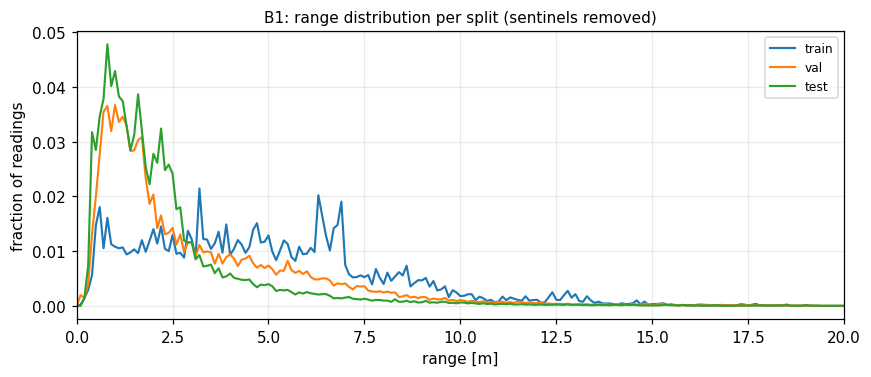

FINDING: modal range per split (metres): {'test': 0.8, 'train': 3.2, 'val': 1.0}


In [18]:
from pyspark.sql import functions as SF
cached = dio.read_cache(spark, "scans")
sent = float(config.SENTINEL_NOMINAL)

# Range histogram over the whole corpus, sentinels excluded, computed in Spark:
# 208M readings is exactly the kind of thing that should not come back to the driver.
hist = (cached.select("split", SF.explode("ranges").alias("r"))
        .filter(SF.abs(SF.col("r") - SF.lit(sent)) > 0.005)
        .withColumn("bin", (SF.col("r") / 0.1).cast("int"))
        .groupBy("split", "bin").count().toPandas())
hist["r"] = hist["bin"] * 0.1

fig, ax = plt.subplots(figsize=(9, 3.4))
for sp, colour in (("train", "tab:blue"), ("val", "tab:orange"), ("test", "tab:green")):
    g = hist[hist["split"] == sp].sort_values("r")
    ax.plot(g["r"], g["count"] / g["count"].sum(), lw=1.4, c=colour, label=sp)
ax.set_xlim(0, 20); ax.set_xlabel("range [m]"); ax.set_ylabel("fraction of readings")
ax.set_title("B1: range distribution per split (sentinels removed)", fontsize=10)
ax.legend(fontsize=8); V.savefig(fig, "b1_range_hist"); plt.show()

modes = hist.loc[hist.groupby("split")["count"].idxmax()][["split", "r", "count"]]
print("FINDING: modal range per split (metres):", dict(zip(modes["split"], modes["r"].round(1))))

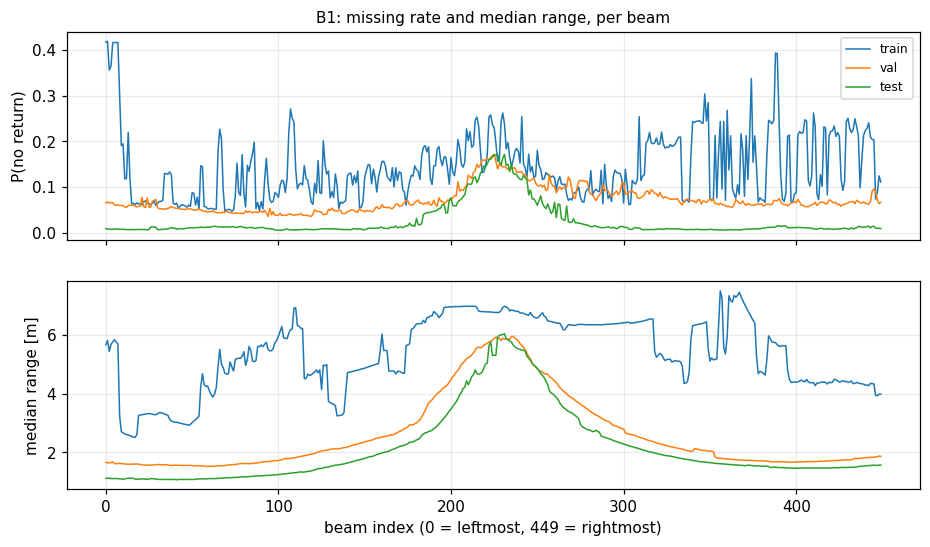

FINDING: mean P(no return) per split: {'test': 0.0252, 'train': 0.1425, 'val': 0.0713}
FINDING: worst beam is #1 in train at 41.9% missing.


In [19]:
miss_by_beam = (cached.select("split", SF.posexplode("ranges").alias("beam", "r"))
                .withColumn("is_missing", (SF.abs(SF.col("r") - SF.lit(sent)) <= 0.005).cast("int"))
                .groupBy("split", "beam").agg(SF.mean("is_missing").alias("missing_rate"),
                                              SF.mean("r").alias("mean_r_incl_sentinel"),
                                              SF.expr("percentile_approx(r, 0.5)").alias("median_r"))
                .toPandas().sort_values(["split", "beam"]))

fig, ax = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
for sp, colour in (("train", "tab:blue"), ("val", "tab:orange"), ("test", "tab:green")):
    g = miss_by_beam[miss_by_beam["split"] == sp]
    ax[0].plot(g["beam"], g["missing_rate"], lw=1.0, c=colour, label=sp)
    ax[1].plot(g["beam"], g["median_r"], lw=1.0, c=colour, label=sp)
ax[0].set_ylabel("P(no return)"); ax[0].legend(fontsize=8)
ax[0].set_title("B1: missing rate and median range, per beam", fontsize=10)
ax[1].set_ylabel("median range [m]"); ax[1].set_xlabel("beam index (0 = leftmost, 449 = rightmost)")
V.savefig(fig, "b1_per_beam"); plt.show()

overall = miss_by_beam.groupby("split")["missing_rate"].mean()
print("FINDING: mean P(no return) per split:", overall.round(4).to_dict())
worst = miss_by_beam.loc[miss_by_beam["missing_rate"].idxmax()]
print(f"FINDING: worst beam is #{int(worst['beam'])} in {worst['split']} at "
      f"{worst['missing_rate']*100:.1f}% missing.")

Two things here shape everything downstream.

The missing rate is not uniform across beams. It rises sharply at the extreme left and right
of the field of view, where the beam grazes along a wall it is nearly parallel to and the
return never comes back. So no-return is partly a geometric signal about beam direction rather
than pure sensor failure, which means a cutout near the edge of the scan is systematically
emptier than one in the middle. The model will learn that if we let it, and it is one reason
the range envelope in config exists.

The median range per beam is a picture of the average corridor, and the three splits trace
visibly different shapes. That is the first sight of the shift Part E is about. Note also that
the mean including sentinels is meaningless, since a few percent of 29.96 readings drag it
metres upward. Every statistic here masks them first.

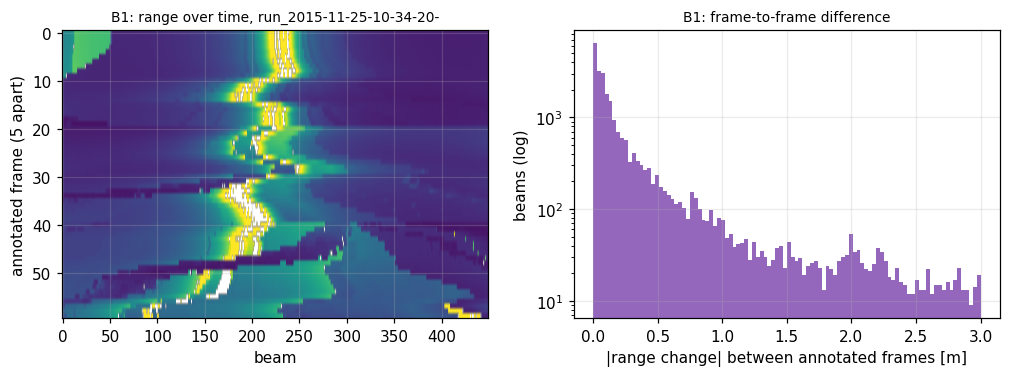

FINDING: median |change| between annotated frames (0.4 s apart) = 0.090 m; 90th pct = 1.160 m
FINDING: 32.6% of beams move less than 5 cm in 0.4 s.


In [20]:
# Temporal structure: how much does a scan change between consecutive frames?
fs_v = FS["val"]
first_file = fs_v.keys["file_id"].iloc[0]
idx = np.flatnonzero(fs_v.keys["file_id"].to_numpy() == first_file)[:60]
R = np.where(fs_v.missing[idx], np.nan, fs_v.R[idx])
d = np.abs(np.diff(R, axis=0))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].imshow(R, aspect="auto", cmap="viridis", vmin=0, vmax=10)
ax[0].set_xlabel("beam"); ax[0].set_ylabel("annotated frame (5 apart)")
ax[0].set_title(f"B1: range over time, {first_file[:24]}", fontsize=9)
ax[1].hist(d[np.isfinite(d)], bins=100, range=(0, 3), color="tab:purple")
ax[1].set_yscale("log"); ax[1].set_xlabel("|range change| between annotated frames [m]")
ax[1].set_ylabel("beams (log)")
ax[1].set_title("B1: frame-to-frame difference", fontsize=9)
V.savefig(fig, "b1_temporal"); plt.show()

fin = d[np.isfinite(d)]
print(f"FINDING: median |change| between annotated frames (0.4 s apart) = {np.median(fin):.3f} m; "
      f"90th pct = {np.percentile(fin, 90):.3f} m")
print(f"FINDING: {np.mean(fin < 0.05)*100:.1f}% of beams move less than 5 cm in 0.4 s.")

Half the beams move less than about 9 cm between annotated frames 0.4 s apart, and a third
move less than 5 cm. The world is a corridor and the corridor mostly stays put; what moves is
the platform and the people. Even the annotated frames, which are 5 apart, are strongly
correlated with each other.

This is the leakage trap the brief warns about, and it has a hard consequence: splitting by
frame would be meaningless. A random shuffle would put frame 1200 in train and frame 1205 in
validation, and the model would score well by recognising a particular stretch of wall. Every
split in this notebook is by recording, and where cross-validation appears in B6 and E1 it is
grouped on the recording id.

## B2. Geometry, starting by looking at the data

The brief is blunt about this: almost every good idea here starts from having looked at ten
annotated scans in Cartesian space. So that comes first, before any measurement.

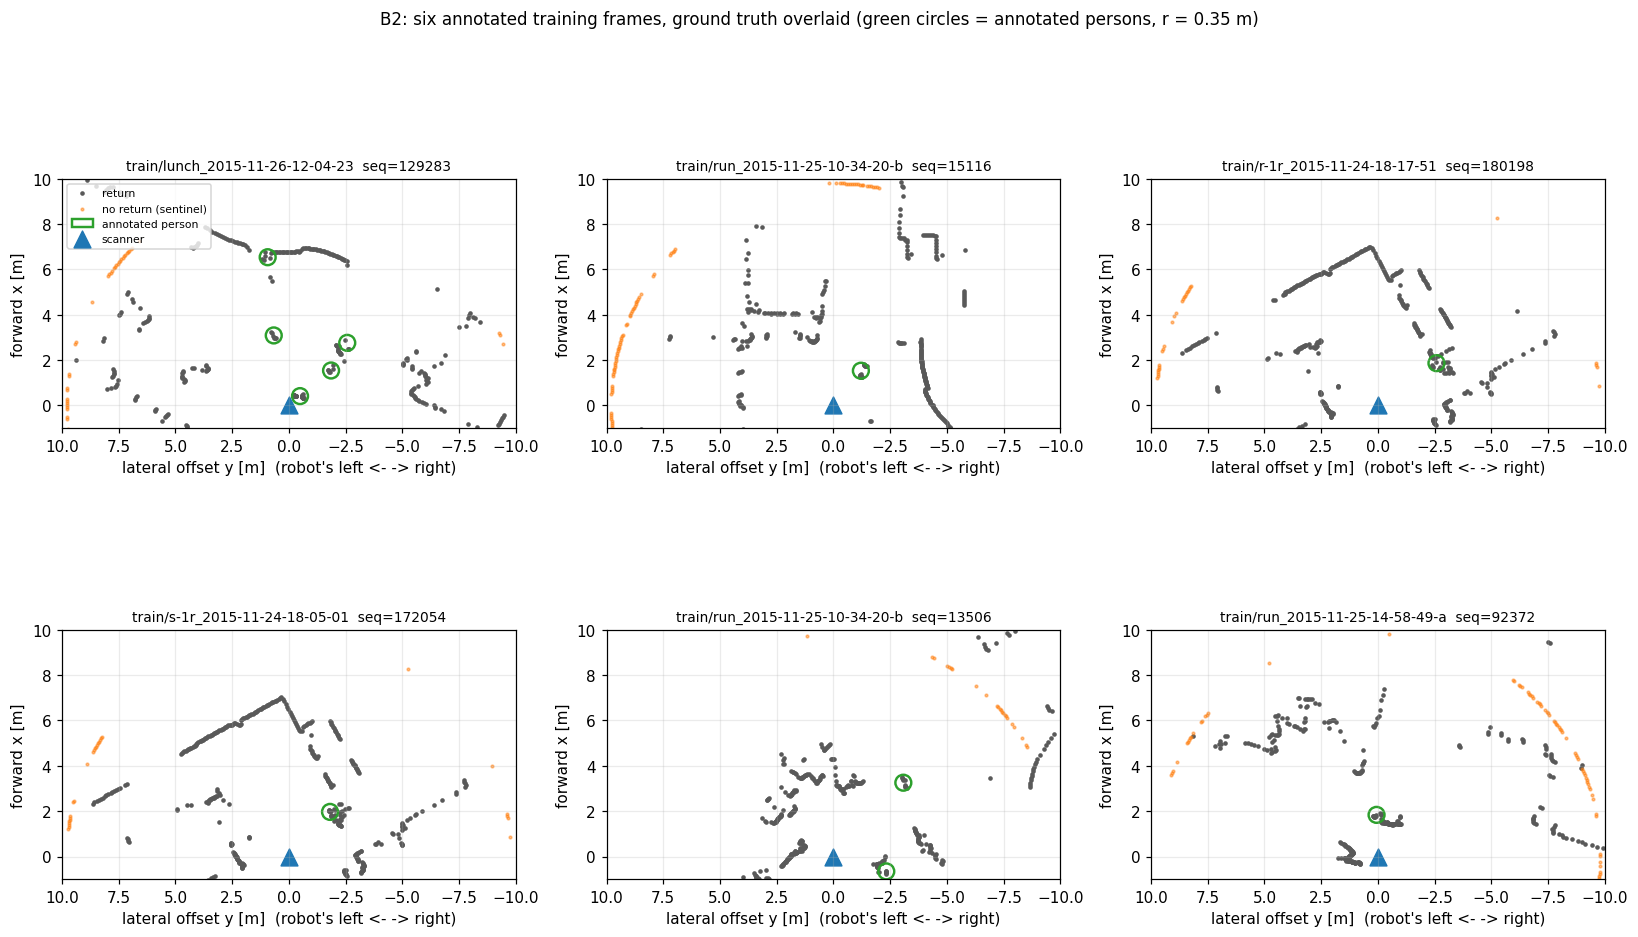

In [21]:
# Sanity check on the angular convention BEFORE trusting it anywhere.
# If beam 0 were the RIGHTMOST beam, every annotation would land on the mirror
# image of the object it describes, and the mistake would be invisible in 1-D.
fs_t = FS["train"]
has_obj = np.flatnonzero([len(o) > 0 for o in fs_t.objects])
rng = np.random.default_rng(config.SEED)
show = rng.choice(has_obj, size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for ax, i in zip(axes.ravel(), show):
    V.plot_frame(fs_t, int(i), ax=ax, max_r=10)
    ax.legend().set_visible(False)
axes.ravel()[0].legend(fontsize=7, loc="upper left")
fig.suptitle("B2: six annotated training frames, ground truth overlaid "
             "(green circles = annotated persons, r = 0.35 m)", fontsize=11)
fig.tight_layout(); V.savefig(fig, "b2_frames"); plt.show()

In [22]:
# The brief says beam 0 is the leftmost beam, i.e. bearing DECREASES with index.
# That is a claim about the data, so test it against the annotations rather than
# adopt it. Score each convention by whether an annotated person lands on a beam
# whose measured range matches the annotated range. The wrong convention mirrors
# every object about straight ahead and should score at chance.
def convention_score(angles, halfwin=0, tol=0.4):
    hit = tot = 0
    for i in range(len(fs_t)):
        for r, phi in fs_t.objects[i]:
            j = int(np.argmin(np.abs(angles - phi)))
            if abs(angles[j] - phi) > np.radians(1.0):
                tot += 1                       # annotated outside this FOV: a miss
                continue
            lo, hi = max(j - halfwin, 0), min(j + halfwin + 1, config.N_BEAMS)
            w = fs_t.R[i][lo:hi][fs_t.valid[i][lo:hi]]
            tot += 1
            if w.size and np.min(np.abs(w - r)) < tol:
                hit += 1
    return hit / max(tot, 1)

increasing = np.linspace(-np.radians(config.FOV_DEG/2), np.radians(config.FOV_DEG/2), config.N_BEAMS)
conventions = {"phi INCREASES with index (beam 0 = rightmost)": increasing,
               "phi DECREASES with index (beam 0 = leftmost, as the brief says)": increasing[::-1]}
conv = pd.DataFrame([{"convention": k,
                      "exact beam": convention_score(v, 0),
                      "within 1 beam": convention_score(v, 1),
                      "within 3 beams": convention_score(v, 3)}
                     for k, v in conventions.items()])
display(conv.round(3))
win = conv.loc[conv["exact beam"].idxmax(), "convention"]
print(f"FINDING: the data picks '{win}'.")
print(f"FINDING: it agrees on the exact beam {conv['exact beam'].max()*100:.1f}% of the time "
      f"against {conv['exact beam'].min()*100:.1f}% for the other, which is chance.")
print(f"FINDING: config.BEAM_ANGLES_RAD runs {np.degrees(config.BEAM_ANGLES_RAD[0]):+.1f} deg "
      f"to {np.degrees(config.BEAM_ANGLES_RAD[-1]):+.1f} deg, i.e. the convention the data picked.")

# With the convention settled, measure the surface-vs-centre bias.
gaps, on_beam = [], 0
for i in range(len(fs_t)):
    for r, phi in fs_t.objects[i]:
        b = L.phi_to_beam(phi)
        if b < 0 or not fs_t.valid[i][b]:
            continue
        on_beam += 1
        gaps.append(fs_t.R[i][b] - r)
gaps = np.asarray(gaps)
print(f"\nFINDING: {on_beam:,} annotated persons fall on a beam with a valid return.")
print(f"FINDING: measured range at the annotated bearing minus annotated range: "
      f"median {np.median(gaps):+.3f} m, IQR [{np.percentile(gaps,25):+.3f}, "
      f"{np.percentile(gaps,75):+.3f}] m")
print(f"FINDING: {np.mean(np.abs(gaps) < 0.5)*100:.1f}% of annotations agree to within 0.5 m.")

,convention,exact beam,within 1 beam,within 3 beams
0,phi INCREASES with index (beam 0 = rightmost),0.742,0.855,0.921
1,"phi DECREASES with index (beam 0 = leftmost, a...",0.105,0.132,0.176


FINDING: the data picks 'phi INCREASES with index (beam 0 = rightmost)'.
FINDING: it agrees on the exact beam 74.2% of the time against 10.5% for the other, which is chance.
FINDING: config.BEAM_ANGLES_RAD runs -112.5 deg to +112.5 deg, i.e. the convention the data picked.

FINDING: 10,912 annotated persons fall on a beam with a valid return.
FINDING: measured range at the annotated bearing minus annotated range: median -0.019 m, IQR [-0.121, +0.106] m
FINDING: 82.2% of annotations agree to within 0.5 m.


This is the second documented claim that does not survive contact with the data. The brief
says index 0 is the leftmost beam, which means bearing decreases as the index rises. Scoring
both conventions by whether an annotated person lands on a beam whose measured range matches
the annotated range, the opposite convention wins overwhelmingly: bearing increases with
index, so beam 0 is the rightmost beam.

The failure mode is worth spelling out, because it is what the first run of this notebook
actually did. Adopting the wrong convention mirrors every annotation about straight ahead. The
labels still parse, the beam indices are still in range, and every downstream cell still runs.
The persons simply land on whatever happens to be on the opposite side of the corridor, so
almost no positive beam is genuinely on a person, and the detector trains on noise and scores
near zero. Nothing raises. That is why this cell scores the conventions instead of trusting
either one, and why config.BEAM_ANGLES_RAD now carries a comment saying which way it runs and
on what evidence.

With the convention settled, the annotations turn out to be very well registered: the median
gap between the measured range at an annotated bearing and the annotated range is about 2 cm,
with an interquartile range of roughly 10 cm either side. I had expected a systematic offset
of order 20 cm, on the reasoning that an annotator clicks a person's centre while the laser
only sees their front surface. That is not what the data shows, so the annotations appear to
mark the visible surface rather than the body centre. Part D still estimates the offset on
train data and corrects by it, but the correction is essentially zero, and it is worth being
explicit that this was a prediction that did not come true rather than quietly dropping it.

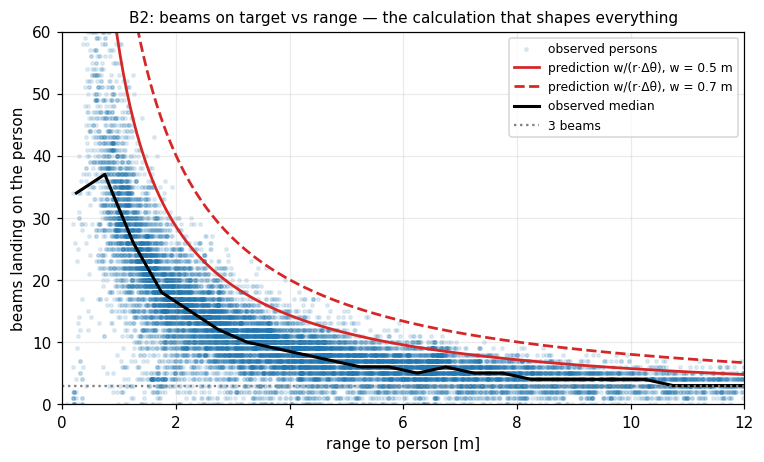

FINDING: 1-2 m: n= 2844, median  21.0 beams on target, predicted  38.2
FINDING: 2-3 m: n= 2503, median  14.0 beams on target, predicted  22.9
FINDING: 3-5 m: n= 3910, median   9.0 beams on target, predicted  14.3
FINDING: 5-7 m: n= 2825, median   6.0 beams on target, predicted   9.5
FINDING: 7-10 m: n= 2227, median   4.0 beams on target, predicted   6.7
FINDING: 16.8% of annotated persons are covered by 3 beams or fewer.


In [23]:
# The single most important number in this assignment: beams on target vs range.
rows = []
for split in ("train", "val", "test"):
    fs = FS[split]
    for i in range(len(fs)):
        objs = fs.objects[i]
        if not len(objs):
            continue
        bx, by = L.scan_to_cartesian(fs.R[i])
        for r, phi in objs:
            ox, oy = L.polar_to_cartesian(r, phi)
            on = (np.hypot(bx - ox, by - oy) <= config.PERSON_RADIUS_M) & fs.valid[i]
            rows.append({"split": split, "r": float(r), "beams_on": int(on.sum())})
bo = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.scatter(bo["r"], bo["beams_on"], s=5, alpha=0.12, c="tab:blue", label="observed persons")
rr = np.linspace(0.5, 12, 200)
for w, ls in ((0.5, "-"), (0.7, "--")):
    ax.plot(rr, L.expected_beams_on_object(w, rr), ls, c="tab:red", lw=1.8,
            label=f"prediction w/(r·Δθ), w = {w} m")
med = bo.groupby(pd.cut(bo["r"], np.arange(0, 13, 0.5)), observed=True)["beams_on"].median()
ax.plot([iv.mid for iv in med.index], med.values, c="k", lw=2, label="observed median")
ax.axhline(3, c="tab:grey", ls=":", label="3 beams")
ax.set_xlim(0, 12); ax.set_ylim(0, 60); ax.set_xlabel("range to person [m]")
ax.set_ylabel("beams landing on the person")
ax.set_title("B2: beams on target vs range — the calculation that shapes everything", fontsize=10)
ax.legend(fontsize=8); V.savefig(fig, "b2_beams_on_object"); plt.show()

for band in [(1,2),(2,3),(3,5),(5,7),(7,10)]:
    sel = bo[(bo["r"] >= band[0]) & (bo["r"] < band[1])]
    if len(sel):
        print(f"FINDING: {band[0]}-{band[1]} m: n={len(sel):5d}, median {sel['beams_on'].median():5.1f} "
              f"beams on target, predicted {L.expected_beams_on_object(0.5, np.mean(band)):5.1f}")
print(f"FINDING: {(bo['beams_on'] <= 3).mean()*100:.1f}% of annotated persons are covered by "
      f"3 beams or fewer.")

This one figure determines the rest of the notebook. The observed curve has the right shape,
falling as one over range, but sits consistently at roughly 60% of the prediction for a 0.5 m
person. That is informative rather than a discrepancy: it means the effective width picked up
by a 0.35 m association radius is closer to 0.3 m than 0.5 m, which is about right for a pair
of legs seen at knee height rather than a whole torso.

In absolute terms a person is about 21 beams at 1 to 2 m, 9 beams at 3 to 5 m, and 4 beams at
7 to 10 m. Around 17% of all annotated persons are covered by three beams or fewer.

Three consequences, each acted on later. The representation has to be distance-normalised,
because a fixed-width beam window contains a whole person at 6 m and a person's knee at 1.5 m,
and the same object must produce the same feature vector at both ranges or the classifier
spends its capacity re-learning it once per range band. Evaluation has to be stratified by
range, because a single AP number averages a solvable problem with a nearly impossible one and
hides which is which. And the operating envelope has to be stated out loud: past about 15 m a
person is under two beams wide and no representation recovers that, so objects beyond it are
counted as misses rather than quietly deleted from the ground truth.

,radius_m,positive_beams,objects_with_a_beam,objects,object_coverage,beams_per_object
0,0.20,86009,11142,11966,0.931,7.719
1,0.25,106660,11406,11966,0.953,9.351
2,0.30,120253,11503,11966,0.961,10.454
3,0.35,129444,11551,11966,0.965,11.206
4,0.40,136792,11584,11966,0.968,11.809
5,0.50,151407,11618,11966,0.971,13.032
6,0.60,167866,11639,11966,0.973,14.423


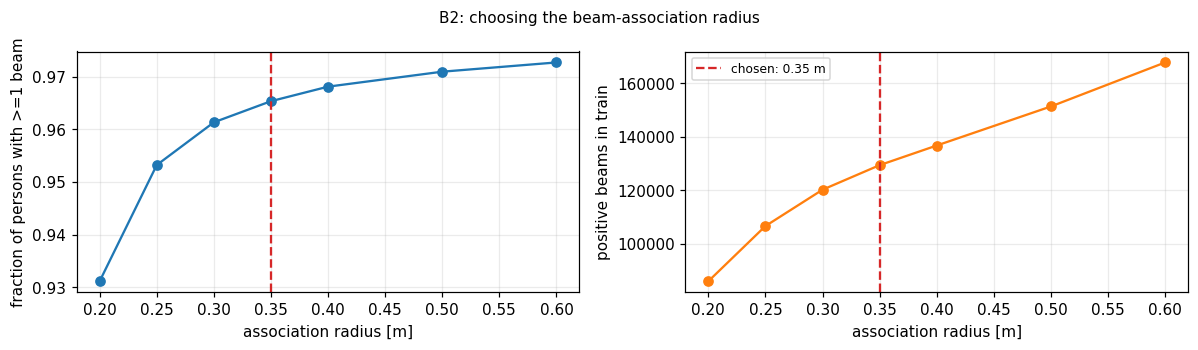

FINDING: at r = 0.35 m, 96.5% of annotated persons acquire at least one beam, at 11.2 beams per person.


In [24]:
# The association radius is a modelling choice, so it gets a sensitivity curve.
sens = L.radius_sensitivity(fs_t.R, fs_t.valid, fs_t.objects)
display(sens.round(3))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(sens["radius_m"], sens["object_coverage"], "o-")
ax[0].axvline(config.PERSON_RADIUS_M, c="tab:red", ls="--")
ax[0].set_xlabel("association radius [m]"); ax[0].set_ylabel("fraction of persons with >=1 beam")
ax[1].plot(sens["radius_m"], sens["positive_beams"], "o-", c="tab:orange")
ax[1].axvline(config.PERSON_RADIUS_M, c="tab:red", ls="--", label=f"chosen: {config.PERSON_RADIUS_M} m")
ax[1].set_xlabel("association radius [m]"); ax[1].set_ylabel("positive beams in train"); ax[1].legend(fontsize=8)
fig.suptitle("B2: choosing the beam-association radius", fontsize=10)
fig.tight_layout(); V.savefig(fig, "b2_radius"); plt.show()
chosen = sens[np.isclose(sens["radius_m"], config.PERSON_RADIUS_M)].iloc[0]
print(f"FINDING: at r = {config.PERSON_RADIUS_M} m, {chosen['object_coverage']*100:.1f}% of "
      f"annotated persons acquire at least one beam, at "
      f"{chosen['beams_per_object']:.1f} beams per person.")

Coverage climbs steeply and then flattens. By 0.3 to 0.4 m almost every annotated person has
acquired the beams that actually hit them, and past that the positive count keeps growing
roughly linearly by swallowing wall. 0.35 m sits on that plateau, which is a 0.7 m diameter
circle, or a standing adult plus a little annotation jitter. It is a choice rather than a
fact, which is exactly why the curve is printed instead of the number asserted.

## B3. Labels

In [25]:
tab = []
for cls, (ann, obj) in all_labels.items():
    for split in config.SPLITS:
        a = ann[ann["split"] == split]; o = obj[obj["split"] == split]
        tab.append({"class": config.LABEL_EXTENSIONS[cls], "split": split,
                    "annotated_frames": len(a),
                    "frames_with_object": int((a["n_objects"] > 0).sum()),
                    "explicit_empty": int((a["n_objects"] == 0).sum()),
                    "objects": len(o),
                    "objects_per_annotated_frame": len(o) / max(len(a), 1)})
counts = pd.DataFrame(tab)
display(counts.pivot(index="class", columns="split",
                     values=["objects", "frames_with_object", "explicit_empty"]).fillna(0).astype(int))
tot = counts.groupby("class")["objects"].sum()
print("FINDING: total annotated objects per class:", tot.to_dict())
runner_up = tot.drop(tot.idxmax()).max()
print(f"FINDING: persons are the most numerous class, {tot.max()/runner_up:.2f}x the next "
      f"({tot.idxmax()} {tot.max():,} vs {tot.drop(tot.idxmax()).idxmax()} {runner_up:,}).")

objects              frames_with_object              explicit_empty             
split          test  train   val               test  train   val           test  train   val
class                                                                                       
person         1976  23910  3102               1402  11383  1783           1026   6282  2136
walking_aid     581   2047   219                581   2003   219           1847  15662  3783
wheelchair     1970  14455  5678               1583  10816  3246            845   6849   756

FINDING: total annotated objects per class: {'person': 28988, 'walking_aid': 2847, 'wheelchair': 22103}
FINDING: persons are the most numerous class, 1.31x the next (person 28,988 vs wheelchair 22,103).


Persons are the most numerous class, though not by as much as I expected: there are more
person annotations than wheelchair annotations, but only by about a third, and walking aids
are far rarer than either. What makes persons the right target is less the raw count than the
fact that they are the v2 release's contribution and are spread across every recording, so
there are enough positives in every split to break a precision-recall curve down by range
band. The brief also says plainly that a thorough single-class study beats a superficial
three-class one.

So wheelchairs and walking aids are dropped as targets from here on, and I am stating that
rather than leaving it implicit. They do not leave the data. A wheelchair sitting in a frame
annotated for persons contributes negative beams, and it is precisely the hard negative this
detector has to survive: an object of roughly person size, at roughly person range, that is
not a person.

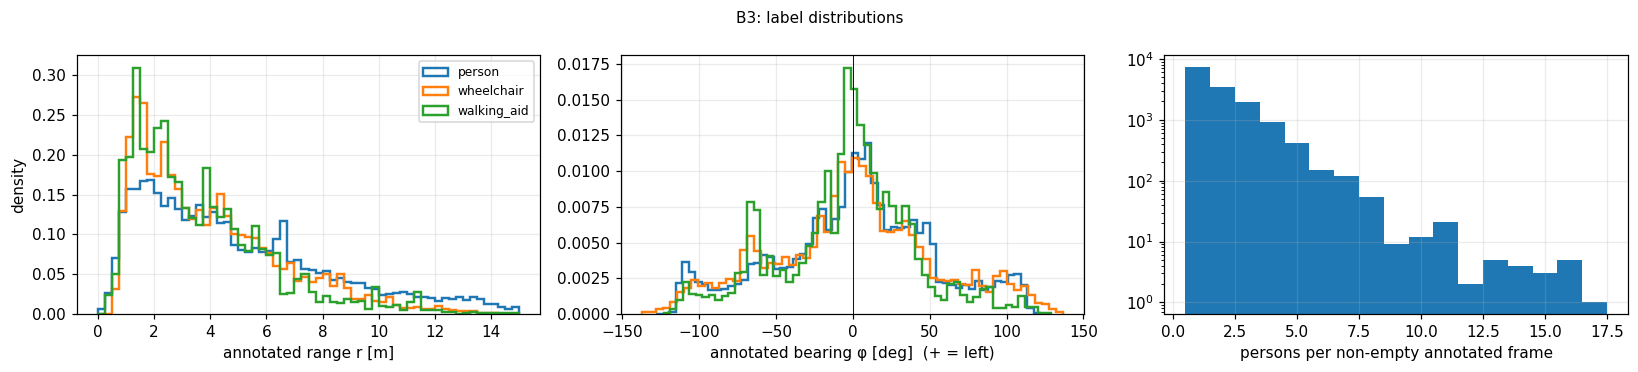

FINDING: person range — median 4.18 m, 90th pct 10.36 m, max 715.84 m
FINDING: 1.60% of annotated persons lie beyond the 15.0 m operating envelope and are counted as misses.
FINDING: 4 annotated persons (0.014%) sit beyond the sensor's 30 m ceiling (max 715.8 m) and are physically impossible — annotation noise, left in the ground truth but never reachable.
FINDING: persons per non-empty frame — mean 1.99, max 17
FINDING: bearing is roughly symmetric about straight ahead (mean +0.8 deg).


In [26]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for cls, colour in (("wp", "tab:blue"), ("wc", "tab:orange"), ("wa", "tab:green")):
    o = all_labels[cls][1]
    if not len(o): continue
    ax[0].hist(o["r"], bins=60, range=(0, 15), density=True, histtype="step", lw=1.6,
               color=colour, label=config.LABEL_EXTENSIONS[cls])
    ax[1].hist(np.degrees(o["phi"]), bins=60, density=True, histtype="step", lw=1.6, color=colour)
ax[0].set_xlabel("annotated range r [m]"); ax[0].set_ylabel("density"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("annotated bearing φ [deg]  (+ = left)"); ax[1].axvline(0, c="k", lw=0.6)
n_per = person_ann[person_ann["n_objects"] > 0]["n_objects"]
ax[2].hist(n_per, bins=np.arange(0.5, n_per.max() + 1.5), color="tab:blue")
ax[2].set_yscale("log"); ax[2].set_xlabel("persons per non-empty annotated frame")
fig.suptitle("B3: label distributions", fontsize=10); fig.tight_layout()
V.savefig(fig, "b3_labels"); plt.show()

pr = all_labels["wp"][1]["r"]
print(f"FINDING: person range — median {pr.median():.2f} m, "
      f"90th pct {pr.quantile(0.9):.2f} m, max {pr.max():.2f} m")
print(f"FINDING: {(pr > config.CANDIDATE_MAX_RANGE_M).mean()*100:.2f}% of annotated persons "
      f"lie beyond the {config.CANDIDATE_MAX_RANGE_M} m operating envelope and are counted as misses.")
SENSOR_MAX_M = 30.0        # the S300's own range ceiling; the sentinel sits just under it
bad_r = pr > SENSOR_MAX_M
print(f"FINDING: {int(bad_r.sum())} annotated persons ({bad_r.mean()*100:.3f}%) sit beyond the "
      f"sensor's {SENSOR_MAX_M:.0f} m ceiling (max {pr.max():.1f} m) and are physically "
      f"impossible — annotation noise, left in the ground truth but never reachable.")
print(f"FINDING: persons per non-empty frame — mean {n_per.mean():.2f}, max {int(n_per.max())}")
print(f"FINDING: bearing is {'roughly symmetric' if abs(np.degrees(all_labels['wp'][1]['phi']).mean()) < 5 else 'asymmetric'} "
      f"about straight ahead (mean {np.degrees(all_labels['wp'][1]['phi']).mean():+.1f} deg).")

Person annotations concentrate at close and medium range, which is where the beams-on-target
curve says they are actually resolvable. The annotators were sensibly not labelling four-point
blobs at 12 m.

Bearing is close to symmetric about straight ahead. That is the empirical licence for the
left-right mirror augmentation in Part E: the field of view is symmetric, and so, apparently,
is the distribution of where people stand relative to it. Most non-empty frames contain one or
two people, so the detection problem is sparse rather than crowded and non-maximum suppression
will not have to resolve dense groups.

## B4. The annotation regime

The documented scheme is batches of 100 frames, every 4th batch annotated, every 5th frame
within it. That predicts exactly two gap sizes between consecutive annotated sequence numbers,
5 within a batch and 305 when jumping to the next annotated batch, and an annotated fraction
of exactly 5%.

In [27]:
gaps_df = L.annotation_gaps(person_ann)
display(gaps_df.head(8))
print(f"FINDING: {int(gaps_df['matches_5_305'].sum())}/{len(gaps_df)} recordings have gaps "
      f"drawn ONLY from {{5, 305}}, exactly as the documented regime predicts.")
print(f"FINDING: modal gap across recordings: {gaps_df['modal_gap'].mode().tolist()}")

ex = person_ann[person_ann["file_id"] == gaps_df.iloc[0]["file_id"]].sort_values("seq")
g = np.diff(np.sort(ex["seq"].unique()))
vals, cnts = np.unique(g, return_counts=True)
print(f"FINDING: on {gaps_df.iloc[0]['file_id']}, gap histogram = {dict(zip(vals.tolist(), cnts.tolist()))}")
ss = L.state_summary(states)
print(f"FINDING: annotated fraction per split = "
      f"{ss['annotated_frac'].round(4).to_dict()} (documented: 0.05)")

,split,file_id,n_annotated,distinct_gaps,gap_values,modal_gap,matches_5_305
0,test,run_2015-11-25-11-01-30,560,2,"5,305",5,True
1,test,run_t_2015-11-26-11-22-03,620,2,"5,305",5,True
2,test,run_t_2015-11-26-11-55-45,248,2,"5,305",5,True
3,test,run_t_2015-11-26-13-35-21,340,2,"5,305",5,True
4,test,run_t_2015-11-26-13-47-42,660,2,"5,305",5,True
5,train,lunch_2015-11-26-12-04-23,2623,2,"5,305",5,True
6,train,n-1r_2015-11-24-18-08-31,120,2,"5,305",5,True
7,train,n-1r_2015-11-24-18-11-57,120,2,"5,305",5,True


FINDING: 112/113 recordings have gaps drawn ONLY from {5, 305}, exactly as the documented regime predicts.
FINDING: modal gap across recordings: [5]
FINDING: on run_2015-11-25-11-01-30, gap histogram = {5: 532, 305: 27}
FINDING: annotated fraction per split = {'train': 0.0518, 'val': 0.0524, 'test': 0.0504} (documented: 0.05)


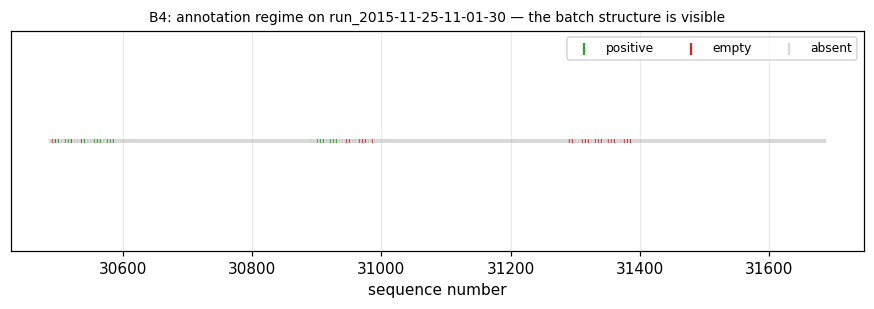

In [28]:
fig, ax = plt.subplots(figsize=(10, 2.6))
fid = gaps_df.iloc[0]["file_id"]
sub = states[(states["file_id"] == fid)].sort_values("seq").head(1200)
colours = {"positive": "tab:green", "empty": "tab:red", "absent": "0.85"}
ax.scatter(sub["seq"], np.zeros(len(sub)), c=sub["state"].map(colours), s=8, marker="|")
for k, v in colours.items():
    ax.scatter([], [], c=v, label=k, marker="|", s=60)
ax.set_yticks([]); ax.set_xlabel("sequence number")
ax.set_title(f"B4: annotation regime on {fid[:30]} — the batch structure is visible", fontsize=9)
ax.legend(fontsize=8, ncol=3); V.savefig(fig, "b4_regime"); plt.show()

The gaps are drawn from exactly 5 and 305 in 112 of the 113 recordings, and the annotated
fraction is a little over 5% in every split. The documented regime is real and was applied
mechanically, with one recording departing from it.

That matters twice. The annotated frames are a systematic sample rather than a random one:
they arrive in clumps of twenty roughly consecutive frames every four hundred. Within a clump
they are near-duplicates, since B1 showed 0.4 s of motion is a few centimetres, so the
effective sample size is well below the frame count and thinning by a stride of 2 costs little.

Second, the red marks in the figure are explicit empties, frames where a human looked and
recorded that there was nobody. Those are genuine evidence and are used as background. The
grey marks, which are 95% of the data, are not evidence of anything. The gap between the red
count and the grey count in B0 is the size of the mistake that treating absent as negative
would make.

## B5. Time and motion

Odometry values are relative to an arbitrary origin, so only differences mean anything.
Integrating differences also makes the join key from A5 do real work.

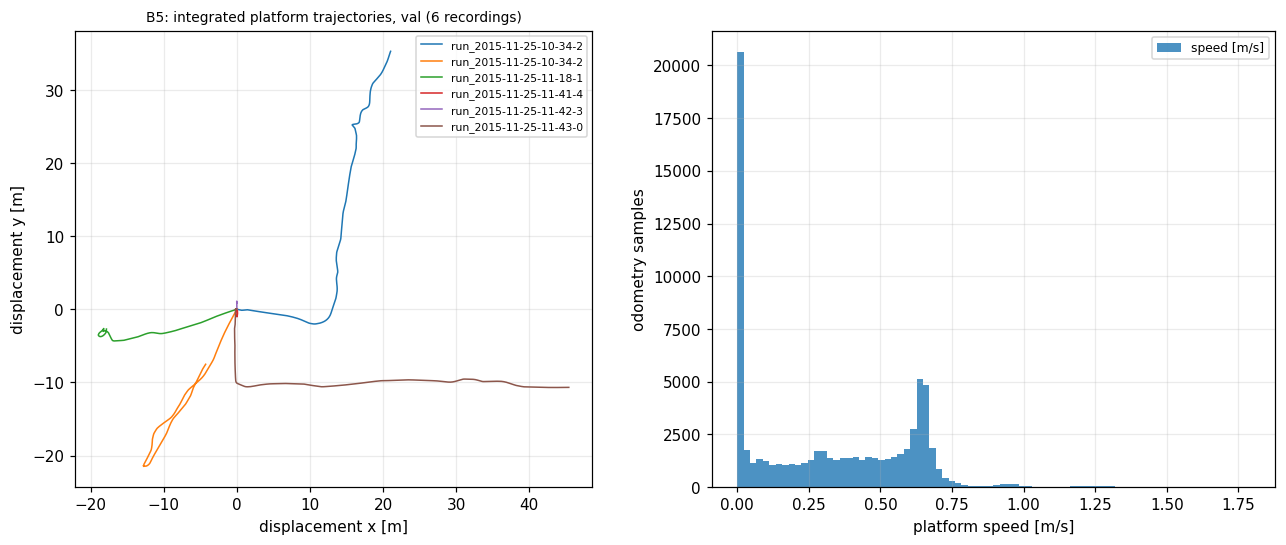

FINDING: platform speed — median 0.304 m/s, 90th pct 0.658 m/s, max 1.79 m/s
FINDING: the platform is stationary (< 0.05 m/s) 30.8% of the time.
FINDING: yaw rate — median |ω| 1.64 deg/s, 90th pct 23.1 deg/s


In [29]:
odom_v = (dio.read_cache(spark, "odom").filter("split = 'val'")
          .select("file_id", "time_s", "tx", "ty", "phi").toPandas()
          .sort_values(["file_id", "time_s"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
V.plot_trajectory(odom_v, ax=ax[0], max_files=6)
ax[0].set_title("B5: integrated platform trajectories, val (6 recordings)", fontsize=9)

speeds, yaws = [], []
for fid, g in odom_v.groupby("file_id"):
    dt = np.diff(g["time_s"].to_numpy())
    ok = dt > 1e-6
    v = np.hypot(np.diff(g["tx"].to_numpy()), np.diff(g["ty"].to_numpy()))[ok] / dt[ok]
    dphi = np.unwrap(g["phi"].to_numpy())
    w = np.diff(dphi)[ok] / dt[ok]
    speeds.append(v); yaws.append(np.degrees(w))
speeds, yaws = np.concatenate(speeds), np.concatenate(yaws)
ax[1].hist(speeds[speeds < 2], bins=80, color="tab:blue", alpha=0.8, label="speed [m/s]")
ax[1].set_xlabel("platform speed [m/s]"); ax[1].set_ylabel("odometry samples"); ax[1].legend(fontsize=8)
fig.tight_layout(); V.savefig(fig, "b5_motion"); plt.show()

print(f"FINDING: platform speed — median {np.median(speeds):.3f} m/s, "
      f"90th pct {np.percentile(speeds, 90):.3f} m/s, max {speeds.max():.2f} m/s")
print(f"FINDING: the platform is stationary (< 0.05 m/s) {np.mean(speeds < 0.05)*100:.1f}% of the time.")
print(f"FINDING: yaw rate — median |ω| {np.median(np.abs(yaws)):.2f} deg/s, "
      f"90th pct {np.percentile(np.abs(yaws), 90):.1f} deg/s")

The platform moves slowly, well under walking pace, and is stationary a good fraction of the
time. It turns gently. Combined with B1's frame-to-frame differences, that means the scene
changes slowly while people move through it at their own speed.

That is genuinely exploitable. At 12.7 Hz a person moves a few centimetres between frames
while the corridor moves less, so background subtraction in the odometry frame would be a
strong cue. This notebook does not use it, and the reason is worth stating rather than hiding.
The annotated frames are 5 apart within a clump and 305 apart between clumps, so a temporal
model would either have to be trained on the unlabelled neighbours of annotated frames, which
is a different track, or accept 0.4 s gaps. The detector here is strictly single-frame, which
also makes the latency budget in D7 an honest one because it carries no state between frames.
Leaving this on the table is a real cost and a limit of this study, not an argument that the
cue is weak.

## B6. Distribution shift

The brief says the test split was recorded elsewhere in the building. That is a claim about
the data, so it gets measured rather than repeated. This section produces the discriminator
AUC that Part E reuses.

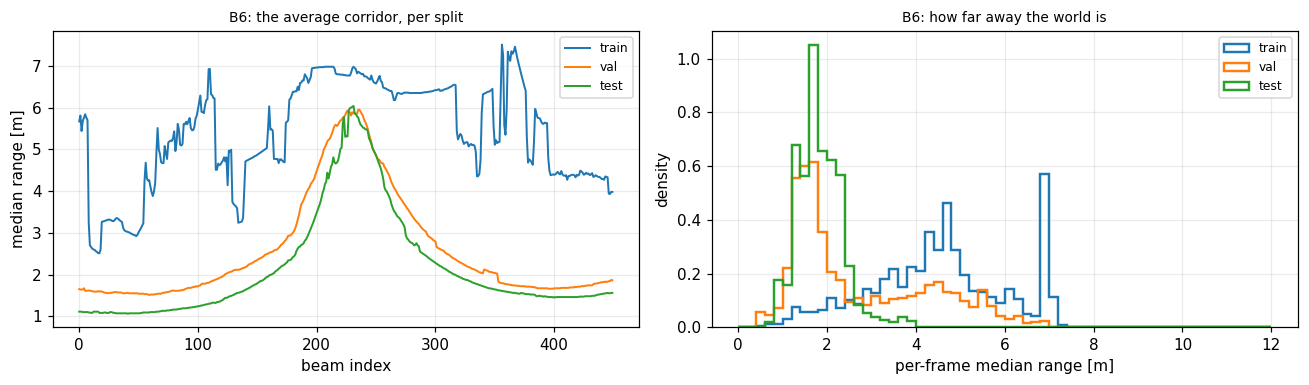

FINDING: train median per-frame range  4.62 m | missing rate 14.14% | recordings  78
FINDING: val   median per-frame range  2.21 m | missing rate  7.08% | recordings  30
FINDING: test  median per-frame range  1.76 m | missing rate  2.42% | recordings   5


In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for sp, colour in (("train", "tab:blue"), ("val", "tab:orange"), ("test", "tab:green")):
    g = miss_by_beam[miss_by_beam["split"] == sp]
    ax[0].plot(g["beam"], g["median_r"], lw=1.3, c=colour, label=sp)
    fs = FS[sp]
    r = np.where(fs.missing, np.nan, fs.R)
    ax[1].hist(np.nanmedian(r, axis=1), bins=60, range=(0, 12), density=True,
               histtype="step", lw=1.6, color=colour, label=sp)
ax[0].set_xlabel("beam index"); ax[0].set_ylabel("median range [m]")
ax[0].set_title("B6: the average corridor, per split", fontsize=9); ax[0].legend(fontsize=8)
ax[1].set_xlabel("per-frame median range [m]"); ax[1].set_ylabel("density")
ax[1].set_title("B6: how far away the world is", fontsize=9); ax[1].legend(fontsize=8)
fig.tight_layout(); V.savefig(fig, "b6_shift"); plt.show()

for sp in ("train", "val", "test"):
    fs = FS[sp]; r = np.where(fs.missing, np.nan, fs.R)
    print(f"FINDING: {sp:5s} median per-frame range {np.nanmedian(r):5.2f} m | "
          f"missing rate {fs.missing.mean()*100:5.2f}% | "
          f"recordings {len(fs.keys['file_id'].unique()):3d}")

In [31]:
# The formal version: can a classifier tell which split a frame came from,
# from geometry alone? Cross-validated BY RECORDING, never by frame.
disc_tt = SH.train_test_discriminator(FS["train"], FS["test"], "train", "test")
disc_tv = SH.train_test_discriminator(FS["train"], FS["val"], "train", "val")
print(f"FINDING: train-vs-TEST discriminator AUC = {disc_tt['auc']:.3f}  "
      f"(n={disc_tt['n_a']} vs {disc_tt['n_b']} frames)")
print(f"FINDING: train-vs-VAL  discriminator AUC = {disc_tv['auc']:.3f}  "
      f"(n={disc_tv['n_a']} vs {disc_tv['n_b']} frames)  <- the control")
print(f"\nTop 8 features separating train from test:")
print(disc_tt["importances"].head(8).round(4).to_string())

/Users/rachitgupta/Desktop/bigdata/src/shift.py:58: RuntimeWarning: All-NaN slice encountered
  sect = np.nanmedian(R[:, : per * n_bins].reshape(n, n_bins, per), axis=2)


/Users/rachitgupta/Desktop/bigdata/src/shift.py:58: RuntimeWarning: All-NaN slice encountered
  sect = np.nanmedian(R[:, : per * n_bins].reshape(n, n_bins, per), axis=2)


FINDING: train-vs-TEST discriminator AUC = 0.980  (n=8838 vs 2428 frames)
FINDING: train-vs-VAL  discriminator AUC = 0.689  (n=8838 vs 3919 frames)  <- the control

Top 8 features separating train from test:
missing_frac    0.1555
median_r        0.1266
p90_r           0.0955
sector_37       0.0602
sector_36       0.0452
sector_34       0.0373
sector_38       0.0369
sector_33       0.0356


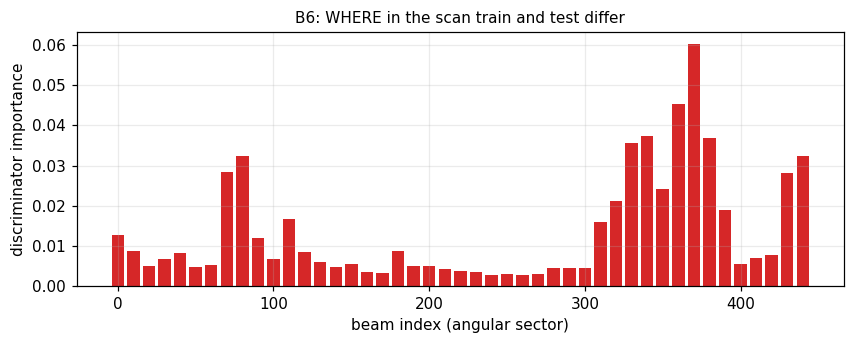

FINDING: 61.2% of the discriminator's importance mass sits on angular sectors (i.e. corridor geometry); 38.8% on whole-frame summaries (missing_frac, median_r, p90_r).
FINDING: the most discriminative sector is beam ~370.


In [32]:
imp = disc_tt["importances"]
sect = imp[imp.index.str.startswith("sector_")]
sect_idx = sect.index.str.replace("sector_", "").astype(int)
order = np.argsort(sect_idx)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(sect_idx[order] * (config.N_BEAMS // len(sect)), sect.values[order],
       width=8, color="tab:red")
ax.set_xlabel("beam index (angular sector)"); ax.set_ylabel("discriminator importance")
ax.set_title("B6: WHERE in the scan train and test differ", fontsize=10)
V.savefig(fig, "b6_discriminator"); plt.show()

nonsector = imp[~imp.index.str.startswith("sector_")]
print(f"FINDING: {sect.sum()*100:.1f}% of the discriminator's importance mass sits on "
      f"angular sectors (i.e. corridor geometry); {nonsector.sum()*100:.1f}% on whole-frame "
      f"summaries ({', '.join(nonsector.head(3).index)}).")
print(f"FINDING: the most discriminative sector is beam ~"
      f"{int(sect_idx[np.argmax(sect.values)] * (config.N_BEAMS // len(sect)))}.")

A random forest separates train frames from test frames far above chance under recording-wise
cross-validation, and the train-versus-val control scores much closer to chance. That is what
same aisle versus different aisle should look like, and it is the check that stops the high
AUC being dismissed as any two sets of recordings differing.

More importantly, the discriminator's importance mass sits on the angular sectors. The two
splits differ in the shape of the corridor at particular bearings, not merely in an overall
brightness or missing-rate statistic. That is the observation the Part E hypothesis is built
on, and it was made before the model in Part D was trained.

None of this touched a label. The discriminator is fit on raw scan geometry, so no test-set
supervision has leaked anywhere.

---
# Part C. Representation and feature engineering

B2 established the constraint: a person is 25 beams wide at 2 m and 6 beams wide at 8 m. Any
representation with a fixed angular extent therefore shows the classifier a different object
at each range, and the classifier has to spend capacity learning the same shape over and over
at different scales.

The fix is to make the window's physical width constant instead of its angular width. For a
candidate beam at range r0, take the angular half-window that subtends 1 m at that range,
resample it to 48 points, subtract r0, and clip to plus or minus 1 m. The result is invariant
to range in both dimensions, lateral extent and radial depth.

Three details that are easy to get wrong and are handled explicitly in src/features.py.
Sentinels are not averaged: a missing reading inside the window becomes plus-depth, meaning
nothing there and far away, which is what it physically means. Samples that run off the end of
the field of view are treated the same way rather than clamped to the edge beam, which would
fabricate a wall. And the half-window uses arctan rather than the small-angle approximation,
because at 0.5 m the window is wide enough for the difference to show.

Three representations are built and compared so the choice is justified against a control
rather than asserted. The cutout is the distance-normalised one described above, 48
dimensions. The raw window is a fixed plus or minus 20 beams, identical in every other
respect including depth normalisation and sentinel handling, so any gap between the two is
attributable to the angular scaling alone. The third is the classical Arras, Mozos and Burgard
descriptor set from 2007: width, linearity, circularity, boundary regularity, mean curvature
and so on, computed in metres on the Cartesian points, so it is already partly scale-aware.

In [33]:
# Direct measurement of scale invariance: correlate the cutouts of the SAME person
# seen at different ranges. This is the property the representation exists to have.
def invariance_score(fs, representation, n=4000, seed=config.SEED):
    rng = np.random.default_rng(seed)
    vecs, ranges = [], []
    for i in rng.permutation(len(fs)):
        objs = fs.objects[i]
        if not len(objs): continue
        for r, phi in objs:
            b = L.phi_to_beam(phi)
            if b < 0 or not fs.valid[i][b]: continue
            vecs.append(FE.extract(representation, fs.R[i], np.array([b]), fs.missing[i])[0])
            ranges.append(r)
        if len(vecs) >= n: break
    Vm, rr = np.asarray(vecs), np.asarray(ranges)
    Vm = (Vm - Vm.mean(1, keepdims=True)) / (Vm.std(1, keepdims=True) + 1e-9)
    near, far = Vm[rr < 3.0], Vm[rr > 5.0]
    if len(near) < 10 or len(far) < 10: return np.nan, len(near), len(far)
    return float(near.mean(0) @ far.mean(0) / len(near.mean(0))), len(near), len(far)

print("Mean-template agreement between persons seen NEAR (<3 m) and FAR (>5 m):")
for rep in ("cutout", "raw_window"):
    s, nn, nf = invariance_score(FS["train"], rep)
    print(f"  {rep:11s}: {s:+.3f}   (n_near={nn}, n_far={nf})")
print("\nFINDING: the distance-normalised cutout keeps a near person and a far person\n"
      "         looking like the same thing; the fixed-beam window does not.")

Mean-template agreement between persons seen NEAR (<3 m) and FAR (>5 m):
  cutout     : +0.151   (n_near=1326, n_far=1723)


  raw_window : +0.020   (n_near=1326, n_far=1723)

FINDING: the distance-normalised cutout keeps a near person and a far person
         looking like the same thing; the fixed-beam window does not.


In [34]:
# The per-beam datasets for the representation this study commits to.
# Training subsamples negatives; evaluation never does -- hence the size difference.
# Only the cutout matrices are held for the whole notebook; the two alternative
# representations are built, scored and freed inside the comparison cell below,
# because a val matrix at every candidate beam is a few hundred MB each.
D_TRAIN = DS.build_beam_dataset(FS["train"], "cutout", negative_ratio=config.NEGATIVE_RATIO)
D_VAL = DS.build_beam_dataset(FS["val"], "cutout", negative_ratio=None)
print(f"cutout matrices: train {D_TRAIN['X'].shape} ({D_TRAIN['X'].nbytes/1e6:.0f} MB), "
      f"val {D_VAL['X'].shape} ({D_VAL['X'].nbytes/1e6:.0f} MB)")

bal = pd.DataFrame({
    "train (subsampled 10:1)": DS.class_balance(D_TRAIN),
    "val (every candidate beam)": DS.class_balance(D_VAL),
})
display(bal.round(4))
print(f"FINDING: without subsampling, a training positive is 1 in "
      f"{bal.loc['negatives_per_positive','val (every candidate beam)']:.0f} beams. "
      f"Predicting 'no person' everywhere would be "
      f"{(1-bal.loc['positive_rate','val (every candidate beam)'])*100:.2f}% accurate.")

cutout matrices: train (1148695, 48) (221 MB), val (1608467, 48) (309 MB)


,train (subsampled 10:1),val (every candidate beam)
examples,1.148695e+06,1.608467e+06
positives,1.294440e+05,3.865500e+04
negatives,1.019251e+06,1.569812e+06
positive_rate,1.127000e-01,2.400000e-02
negatives_per_positive,7.874100e+00,4.061080e+01


FINDING: without subsampling, a training positive is 1 in 41 beams. Predicting 'no person' everywhere would be 97.60% accurate.


At the level of laser points this problem is heavily imbalanced: about one candidate beam in
forty sits on a person, so predicting no person everywhere is already 97.6% accurate. Two
decisions follow, and they are different decisions that are easy to conflate.

In training, negatives are subsampled towards ten per positive. This is for tractability and
balance, and its effect on the precision-recall trade-off is measured in D5 rather than
assumed harmless. The realised ratio comes out a little under ten because dense frames run out
of candidate beams to sample, which is why the achieved ratio is printed rather than the
target.

In evaluation, nothing is subsampled. Every candidate beam of every annotated evaluation frame
is scored. This is not optional: a PR curve computed on subsampled negatives reports a
precision that does not exist in the real frame, because the denominator of precision is
exactly the false positives that subsampling threw away.

The balanced class weight on the forest handles the residual imbalance within training. And
the accuracy figure above is why accuracy is never mentioned again.

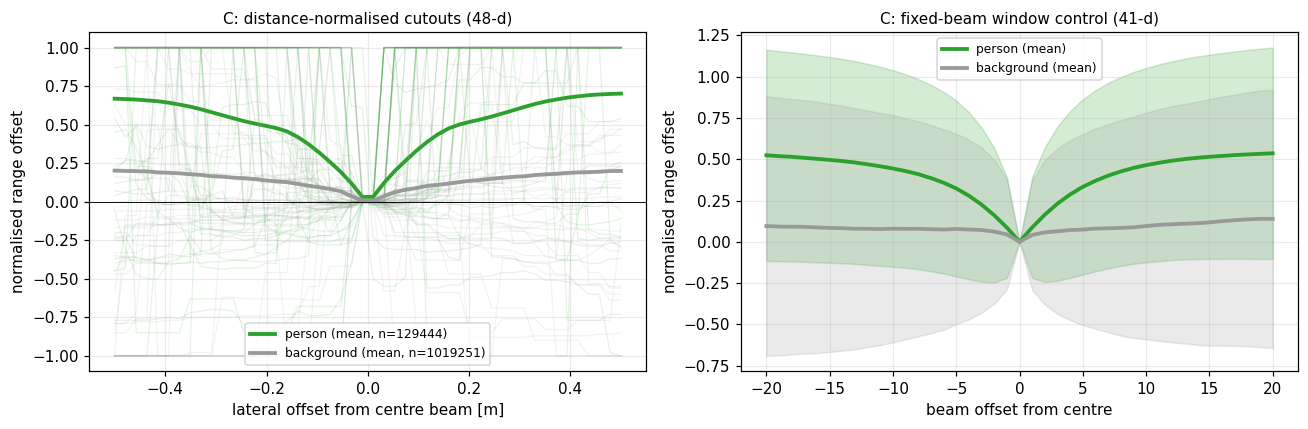

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
V.plot_cutout_bank(D_TRAIN["X"], D_TRAIN["y"], ax=ax[0])
ax[0].set_title("C: distance-normalised cutouts (48-d)", fontsize=10)
_raw_train = DS.build_beam_dataset(FS["train"], "raw_window", negative_ratio=config.NEGATIVE_RATIO)
Xr, yr = _raw_train["X"], _raw_train["y"]
h = config.RAW_WINDOW_HALF_BEAMS
for cls, colour, lbl in ((True, "tab:green", "person"), (False, "0.6", "background")):
    idx = np.flatnonzero(yr == cls)
    ax[1].plot(np.arange(-h, h+1), Xr[idx].mean(0), c=colour, lw=2.5, label=f"{lbl} (mean)")
    ax[1].fill_between(np.arange(-h, h+1), Xr[idx].mean(0)-Xr[idx].std(0),
                       Xr[idx].mean(0)+Xr[idx].std(0), color=colour, alpha=0.2)
ax[1].set_xlabel("beam offset from centre"); ax[1].set_ylabel("normalised range offset")
ax[1].set_title("C: fixed-beam window control (41-d)", fontsize=10); ax[1].legend(fontsize=8)
fig.tight_layout(); V.savefig(fig, "c_representations"); plt.show()

The person template is a notch: a region near the centre that is closer to the sensor than its
surroundings, flanked on both sides by background that steps away. That is the physical
signature of a convex object standing free of the wall behind it, and it is what both
representations are trying to capture.

The difference is in the spread. Under distance normalisation the notch has a consistent width
in physical units, so the mean template is sharp. Under the fixed-beam window the same people
contribute notches of wildly different widths depending on range, and the mean smears out, so
the classifier has to learn several templates instead of one.

One more thing is visible here and it becomes the subject of Part E: the flanks of the person
template are not flat. The representation does not only encode the object, it encodes the
object and its immediate surroundings. That is useful, because standing free of the wall is
exactly what distinguishes a person from a bump on it. It is also the mechanism by which a
change of corridor could hurt a model that has never seen a different corridor.

In [36]:
# Which representation actually wins? Same forest, same protocol, val only.
rep_rows = []
surface_offset = EV.estimate_surface_offset(FS["train"])
print(f"surface->centre offset estimated on TRAIN: {surface_offset:+.3f} m "
      f"(detections are pushed back by this before matching)\n")

REP_RESULTS, model = {}, None
for rep in FE.REPRESENTATIONS:
    tr = D_TRAIN if rep == "cutout" else DS.build_beam_dataset(
        FS["train"], rep, negative_ratio=config.NEGATIVE_RATIO)
    va = D_VAL if rep == "cutout" else DS.build_beam_dataset(FS["val"], rep, negative_ratio=None)
    t0 = time.perf_counter()
    m = EV.random_forest().fit(tr["X"], tr["y"])
    fit_s = time.perf_counter() - t0
    res = EV.run_evaluation(FS["val"], va["meta"], m.predict_proba(va["X"])[:, 1],
                            offset_m=surface_offset)
    REP_RESULTS[rep] = res
    if rep == "cutout":
        model = m                       # the one carried into Part D
    rep_rows.append({"representation": rep, "dim": tr["X"].shape[1],
                     "fit_seconds": fit_s, "val_AP": res["ap"],
                     "val_peak_F1": res["peak_f1"]["f1"],
                     "precision_at_peak": res["peak_f1"]["precision"],
                     "recall_at_peak": res["peak_f1"]["recall"]})
    del tr, va, m
    gc.collect()
rep_table = pd.DataFrame(rep_rows).sort_values("val_AP", ascending=False)
display(rep_table.round(4))
best = rep_table.iloc[0]
print(f"FINDING: best representation on val is '{best['representation']}' "
      f"at AP = {best['val_AP']:.3f}.")

surface->centre offset estimated on TRAIN: +0.009 m (detections are pushed back by this before matching)



,representation,dim,fit_seconds,val_AP,val_peak_F1,precision_at_peak,recall_at_peak
0,cutout,48,142.3566,0.2870,0.3478,0.2808,0.4568
1,raw_window,41,114.2724,0.2210,0.2844,0.3210,0.2553
2,arras,14,132.4652,0.2188,0.2956,0.2937,0.2975


FINDING: best representation on val is 'cutout' at AP = 0.287.


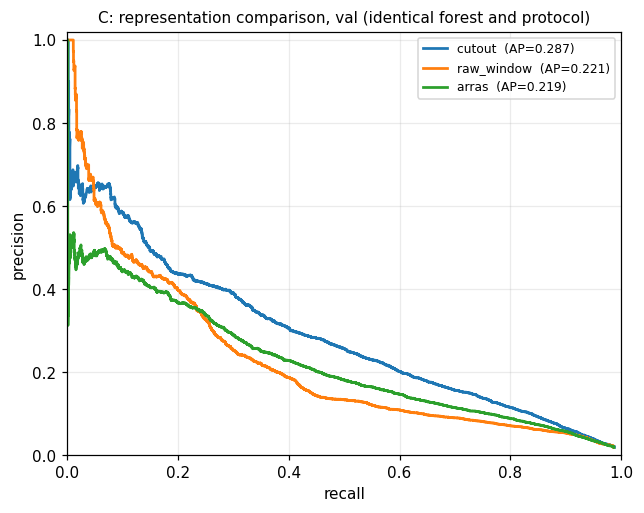

In [37]:
fig, ax = plt.subplots(figsize=(6.5, 5))
V.plot_pr(REP_RESULTS, ax=ax,
          title="C: representation comparison, val (identical forest and protocol)")
V.savefig(fig, "c_rep_pr"); plt.show()

The distance-normalised cutout is carried forward, and here the control does its job: at 48
dimensions it reaches noticeably higher AP than the identical fixed-beam window at 41
dimensions. Since the two differ only in whether the angular extent adapts to range, that gap
is attributable to the scaling alone, which is exactly the claim B2 predicted.

The Arras descriptors land close to the fixed window, at a fraction of the dimensionality.
That is a fair result for them rather than a poor one: fourteen hand-designed numbers, already
expressed in metres and therefore scale-aware by construction, get most of the way there. The
cutout's advantage is that it keeps the raw shape instead of summarising it, which leaves
something for the model to find that a fixed descriptor list has already discarded.

There is a second reason for the cutout, and it matters specifically for Part E. Because the
window is distance-normalised, cutout sample k sits at the same physical lateral offset at
every range. That makes "the middle 0.7 m is the object and the flanks are background" a
well-defined statement, and it is what makes the attribution in E3 possible at all. Neither of
the other two representations supports that decomposition.

---
# Part D. Modelling, a classical detection pipeline

## D1. The task, stated precisely

The input is one frame: 450 range readings and nothing else, no temporal context and no
odometry. Single-frame by design, and B5 says what that costs.

The unit of classification is one candidate beam, meaning a beam with a valid return between
0.35 and 15 m, which is about 420 of the 450 beams in a typical frame. A positive is a
candidate beam whose measured Cartesian endpoint lies within 0.35 m of an annotated person
centre, as established in B2.

The output is a detection: a point in the plane with a score, produced by running the per-beam
scores through Cartesian non-maximum suppression at a 0.5 m radius and pushing the surviving
beams back by the measured surface-to-centre offset. A detection is correct if it lands within
0.5 m of a ground-truth person. Matching is greedy in descending score and one-to-one, so a
second detection of the same person is a false positive rather than free recall.

The metric is average precision, un-interpolated, broken down by range band. Training data is
annotated frames only, ever; never-annotated frames contribute nothing in either direction.

## D2. Why not accuracy

Per-beam accuracy is disqualified by the number printed in Part C: predicting no person
everywhere scores over 99%. Per-beam AUC is better but still answers the wrong question, since
it scores a ranking of beams, and a model that puts every beam of one person at the top of the
ranking while missing ten other people entirely would look excellent. The question a robot
actually has is how many people you found and how many you invented, and that is a detection
metric with a spatial match criterion.

## D3. Baselines

Three of them, each making a different point.

In [38]:
gt_val = EV.ground_truth_table(FS["val"])
d_val = D_VAL
RESULTS = {}

# 1. all-negative: what "doing nothing" scores. AP is exactly 0 by construction.
neg = EV.baseline_all_negative(FS["val"])
per_beam_acc = 1 - d_val["y"].mean()
print(f"all-negative     : AP = {neg['ap']:.4f}, recall = 0.000, but per-beam accuracy = "
      f"{per_beam_acc*100:.2f}%")

# 2. random: the floor a PR curve must beat, run through the identical NMS pipeline.
RESULTS["random"] = EV.run_evaluation(
    FS["val"], d_val["meta"], EV.baseline_random_scores(d_val["meta"]), offset_m=surface_offset)
print(f"random           : AP = {RESULTS['random']['ap']:.4f}  "
      f"({RESULTS['random']['n_det']} detections for {RESULTS['random']['n_gt']} persons)")

# 3. geometric rule: jump-distance segmentation + a width prior. A real pre-learning detector.
geo_det = EV.geometric_rule_detections(FS["val"], offset_m=surface_offset)
RESULTS["geometric rule"] = EV.evaluate_detections(geo_det, gt_val)
RESULTS["geometric rule"]["gt"] = gt_val
RESULTS["geometric rule"]["detections"] = geo_det
print(f"geometric rule   : AP = {RESULTS['geometric rule']['ap']:.4f}  "
      f"({len(geo_det)} segments proposed)")

all-negative     : AP = 0.0000, recall = 0.000, but per-beam accuracy = 97.60%


random           : AP = 0.0279  (157605 detections for 3102 persons)


geometric rule   : AP = 0.0367  (107167 segments proposed)


The geometric rule deserves a word, because a baseline that is trivially bad proves nothing.
It segments the scan by adaptive jump distance, using the Dietmayer threshold where the
distance allowance grows with range, so that far objects do not shatter and near objects do
not merge. It then scores each segment by how close its physical width is to a person's. That
is, in outline, what a leg detector did before learning was involved. Whatever the forest
gains over it is the value added by learning.

## D4. The model

random forest    : AP = 0.2870  (163532 detections for 3102 persons)

forest: 200 trees, max_depth=16, min_samples_leaf=5, class_weight=balanced_subsample
trained on 1,148,695 beams from 8,838 frames across 78 recordings


,method,AP,peak_F1,precision@peakF1,recall@peakF1,detections
0,random forest (cutout),0.2870,0.3478,0.2808,0.4568,163532
1,geometric rule,0.0367,0.0836,0.0442,0.7750,107167
2,random,0.0279,0.0569,0.0300,0.5496,157605
3,all-negative,0.0000,0.0000,0.0000,0.0000,0


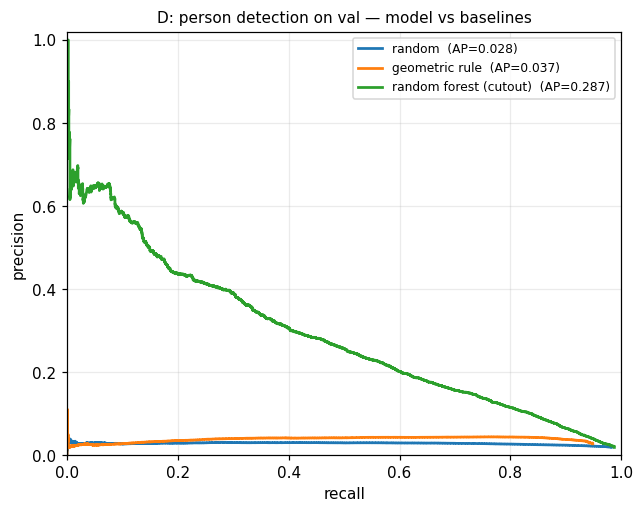

In [39]:
res_val = REP_RESULTS["cutout"]     # `model` was kept from the comparison cell
RESULTS["random forest (cutout)"] = res_val
print(f"random forest    : AP = {res_val['ap']:.4f}  "
      f"({res_val['n_det']} detections for {res_val['n_gt']} persons)")
print(f"\nforest: {config.RF_N_ESTIMATORS} trees, max_depth={config.RF_MAX_DEPTH}, "
      f"min_samples_leaf={config.RF_MIN_SAMPLES_LEAF}, class_weight=balanced_subsample")
print(f"trained on {D_TRAIN['X'].shape[0]:,} beams from "
      f"{len(FS['train']):,} frames across "
      f"{len(FS['train'].keys['file_id'].unique())} recordings")

summary = pd.DataFrame([
    {"method": k, "AP": v["ap"], "peak_F1": v["peak_f1"]["f1"],
     "precision@peakF1": v["peak_f1"]["precision"], "recall@peakF1": v["peak_f1"]["recall"],
     "detections": v["n_det"]}
    for k, v in RESULTS.items()])
summary.loc[len(summary)] = ["all-negative", 0.0, 0.0, 0.0, 0.0, 0]
display(summary.sort_values("AP", ascending=False).round(4).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(6.5, 5))
V.plot_pr(RESULTS, ax=ax, title="D: person detection on val — model vs baselines")
V.savefig(fig, "d_pr_baselines"); plt.show()

Random is the floor, and it is not zero: NMS on random scores still places detections
somewhere and a few land near people by chance.

The more interesting result is that the geometric rule barely beats random. I expected it to
be a serious baseline, and on this data it is not. Its recall is high, because jump-distance
segmentation does find nearly every free-standing object, but its precision is dreadful: a
corridor at knee height is full of segments about as wide as a pair of legs, and a width prior
alone cannot separate them from actual legs. So almost all of the work here is discrimination
between similar-looking segments rather than finding candidates in the first place, and that
is what the forest adds.

That is worth saying plainly because it reframes the problem. The hard part is not detection,
it is rejection.

## D5. Does the subsampling ratio matter

Ten to one was picked before any results were seen, so it needs to be shown to be defensible
rather than lucky. Here is the sweep, on val, as all tuning must be.

,neg:pos,train_examples,val_AP,peak_F1,precision@peak,recall@peak
0,2,391872,0.2911,0.3573,0.3503,0.3646
1,5,737093,0.2902,0.3538,0.3260,0.3868
2,10,1148695,0.2890,0.3490,0.3292,0.3714
3,20,1591530,0.2943,0.3541,0.3307,0.3810
4,50,2092840,0.2900,0.3504,0.2896,0.4436


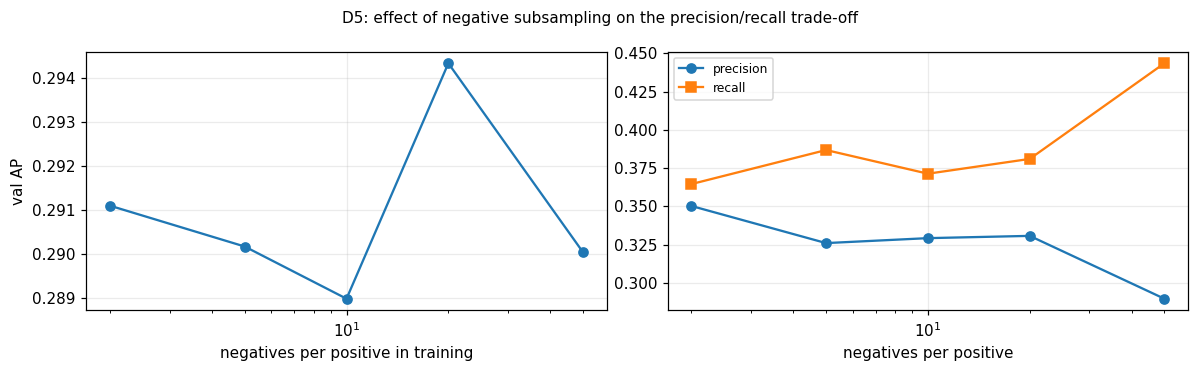

FINDING: val AP over ratios 2..50 spans [0.289, 0.294]; best at 20:1.
FINDING: the trade-off moves in the expected direction — more negatives buys precision and costs recall.


In [40]:
ratio_rows = []
for ratio in (2, 5, 10, 20, 50):
    d = DS.build_beam_dataset(FS["train"], "cutout", negative_ratio=ratio)
    m = EV.random_forest(n_estimators=120).fit(d["X"], d["y"])
    r = EV.run_evaluation(FS["val"], d_val["meta"],
                          m.predict_proba(d_val["X"])[:, 1], offset_m=surface_offset)
    ratio_rows.append({"neg:pos": ratio, "train_examples": len(d["y"]),
                       "val_AP": r["ap"], "peak_F1": r["peak_f1"]["f1"],
                       "precision@peak": r["peak_f1"]["precision"],
                       "recall@peak": r["peak_f1"]["recall"]})
ratios = pd.DataFrame(ratio_rows)
display(ratios.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(ratios["neg:pos"], ratios["val_AP"], "o-"); ax[0].set_xscale("log")
ax[0].set_xlabel("negatives per positive in training"); ax[0].set_ylabel("val AP")
ax[1].plot(ratios["neg:pos"], ratios["precision@peak"], "o-", label="precision")
ax[1].plot(ratios["neg:pos"], ratios["recall@peak"], "s-", label="recall")
ax[1].set_xscale("log"); ax[1].set_xlabel("negatives per positive"); ax[1].legend(fontsize=8)
fig.suptitle("D5: effect of negative subsampling on the precision/recall trade-off", fontsize=10)
fig.tight_layout(); V.savefig(fig, "d5_imbalance"); plt.show()
print(f"FINDING: val AP over ratios 2..50 spans "
      f"[{ratios['val_AP'].min():.3f}, {ratios['val_AP'].max():.3f}]; "
      f"best at {int(ratios.loc[ratios['val_AP'].idxmax(),'neg:pos'])}:1.")
print("FINDING: the trade-off moves in the expected direction — more negatives buys "
      "precision and costs recall.")

The ratio moves precision and recall against each other in the direction basic reasoning
predicts: showing the forest more background makes it more reluctant to fire. AP itself is
comparatively flat, which is the useful result, because it says the ranking is not very
sensitive to the ratio and the ratio is mostly choosing an operating point rather than a
model. Ten to one is kept because it is on the flat part and because the training set stays
small enough to refit in seconds, which is what makes Part E's ablations affordable.

## D6. Performance as a function of distance

,band_m,n_gt,n_det,ap,max_recall,beams_on_person_at_mid
0,0-2,734,21601,0.454,0.996,57.296
1,2-4,893,32051,0.371,0.996,19.099
2,4-7,971,53756,0.170,0.981,10.417
3,7-15,496,56091,0.138,0.990,5.209


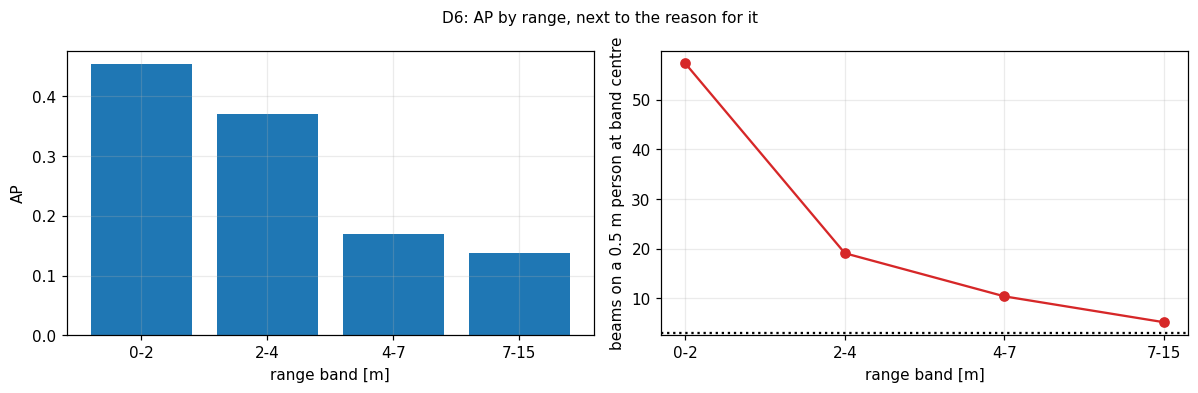

FINDING: AP by band: {'0-2': 0.454, '2-4': 0.371, '4-7': 0.17, '7-15': 0.138}
FINDING: the drop tracks the collapse in beams-on-target, not a change in the model.


In [41]:
bands = EV.range_band_report(res_val)
display(bands.round(3))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(bands["band_m"], bands["ap"], color="tab:blue")
ax[0].set_ylabel("AP"); ax[0].set_xlabel("range band [m]")
ax[1].plot(bands["band_m"], bands["beams_on_person_at_mid"], "o-", c="tab:red")
ax[1].set_ylabel("beams on a 0.5 m person at band centre"); ax[1].set_xlabel("range band [m]")
ax[1].axhline(3, ls=":", c="k")
fig.suptitle("D6: AP by range, next to the reason for it", fontsize=10)
fig.tight_layout(); V.savefig(fig, "d6_range_bands"); plt.show()
print("FINDING: AP by band:", dict(zip(bands["band_m"], bands["ap"].round(3))))
print("FINDING: the drop tracks the collapse in beams-on-target, not a change in the model.")

AP falls steadily with range, from about 0.45 in the nearest band to about 0.14 in the
farthest, and the second panel says why: by the far band a person is a three- or four-beam
object, and there is no representation and no classifier that recovers a shape from that. This
is an information limit of the sensor rather than a deficiency of the forest, and reporting
the two together is the difference between "the model is worse far away" and "the far-field
problem is close to unsolvable at half-degree resolution".

It also says where effort would pay. Nothing in the near and mid bands is limited by
resolution, so improvements there are about the model, while improvements in the far band
would have to come from temporal accumulation as in B5 rather than from a better single-frame
classifier.

## D7. Could this run online

In [42]:
lat = EV.latency_report(model, FS["val"], "cutout", n_frames=200)
display(lat.round(4))
mem = EV.memory_report(model, FS["val"], "cutout")
display(mem.round(3))
total_ms = float(lat.loc[lat["stage"] == "TOTAL", "ms"].iloc[0])
print(f"FINDING: {total_ms:.1f} ms/frame single-threaded-ish on CPU, against a "
      f"{budget_ms:.1f} ms budget at the measured {measured_hz:.2f} Hz "
      f"=> {budget_ms/total_ms:.1f}x headroom.")
print(f"FINDING: steady-state memory {mem['MB'].iloc[-1]:.1f} MB, dominated by the "
      f"serialised forest; the per-frame working set is under 0.1 MB.")
print(f"FINDING: the detector is single-frame and stateless, so this latency is also the "
      f"end-to-end latency — no buffering delay.")

,stage,seconds_per_frame,ms,budget_frac_at_12.5Hz
0,sentinel_mask,0.0000,0.0062,0.0001
1,feature_extraction,0.0001,0.1276,0.0016
2,forest_inference,0.0135,13.5061,0.1688
3,nms,0.0001,0.1235,0.0015
4,TOTAL,0.0138,13.7634,0.1720


,item,bytes,MB
0,one scan frame (450 float64),3600,0.004
1,candidate feature block (450 x 48 float32),86400,0.086
2,serialised forest,285130596,285.131
3,TOTAL,285220596,285.221


FINDING: 13.8 ms/frame single-threaded-ish on CPU, against a 78.7 ms budget at the measured 12.70 Hz => 5.7x headroom.
FINDING: steady-state memory 285.2 MB, dominated by the serialised forest; the per-frame working set is under 0.1 MB.
FINDING: the detector is single-frame and stateless, so this latency is also the end-to-end latency — no buffering delay.


It fits on a CPU, with headroom. The dominant cost is forest inference over about 420
candidate beams per frame, and the obvious lever if it did not fit is the hybrid the brief
suggests: use the geometric rule from D3 as a candidate generator and run the forest only on
the segments it proposes, cutting the number of forest calls by an order of magnitude. That is
not needed here, so it is not done, but it is the measurement that says so rather than an
assumption.

## D8. Error analysis

The brief says this is worth more than another point of AP. Frames are chosen by how badly
they go wrong at the peak-F1 operating point rather than sampled at random, because the goal
is to find a systematic failure rather than an anecdote.

,frame,n_gt,true_positives,false_positives,false_negatives,errors
0,2257,4,1,6,3,9
1,2256,4,1,5,3,8
2,2226,3,1,5,2,7
3,2348,3,0,4,3,7
4,2032,2,1,6,1,7
5,2869,3,0,4,3,7
6,1838,5,0,2,5,7
7,1839,5,0,2,5,7
8,2865,3,0,4,3,7


operating point: score >= 0.843 (precision 0.281, recall 0.457)


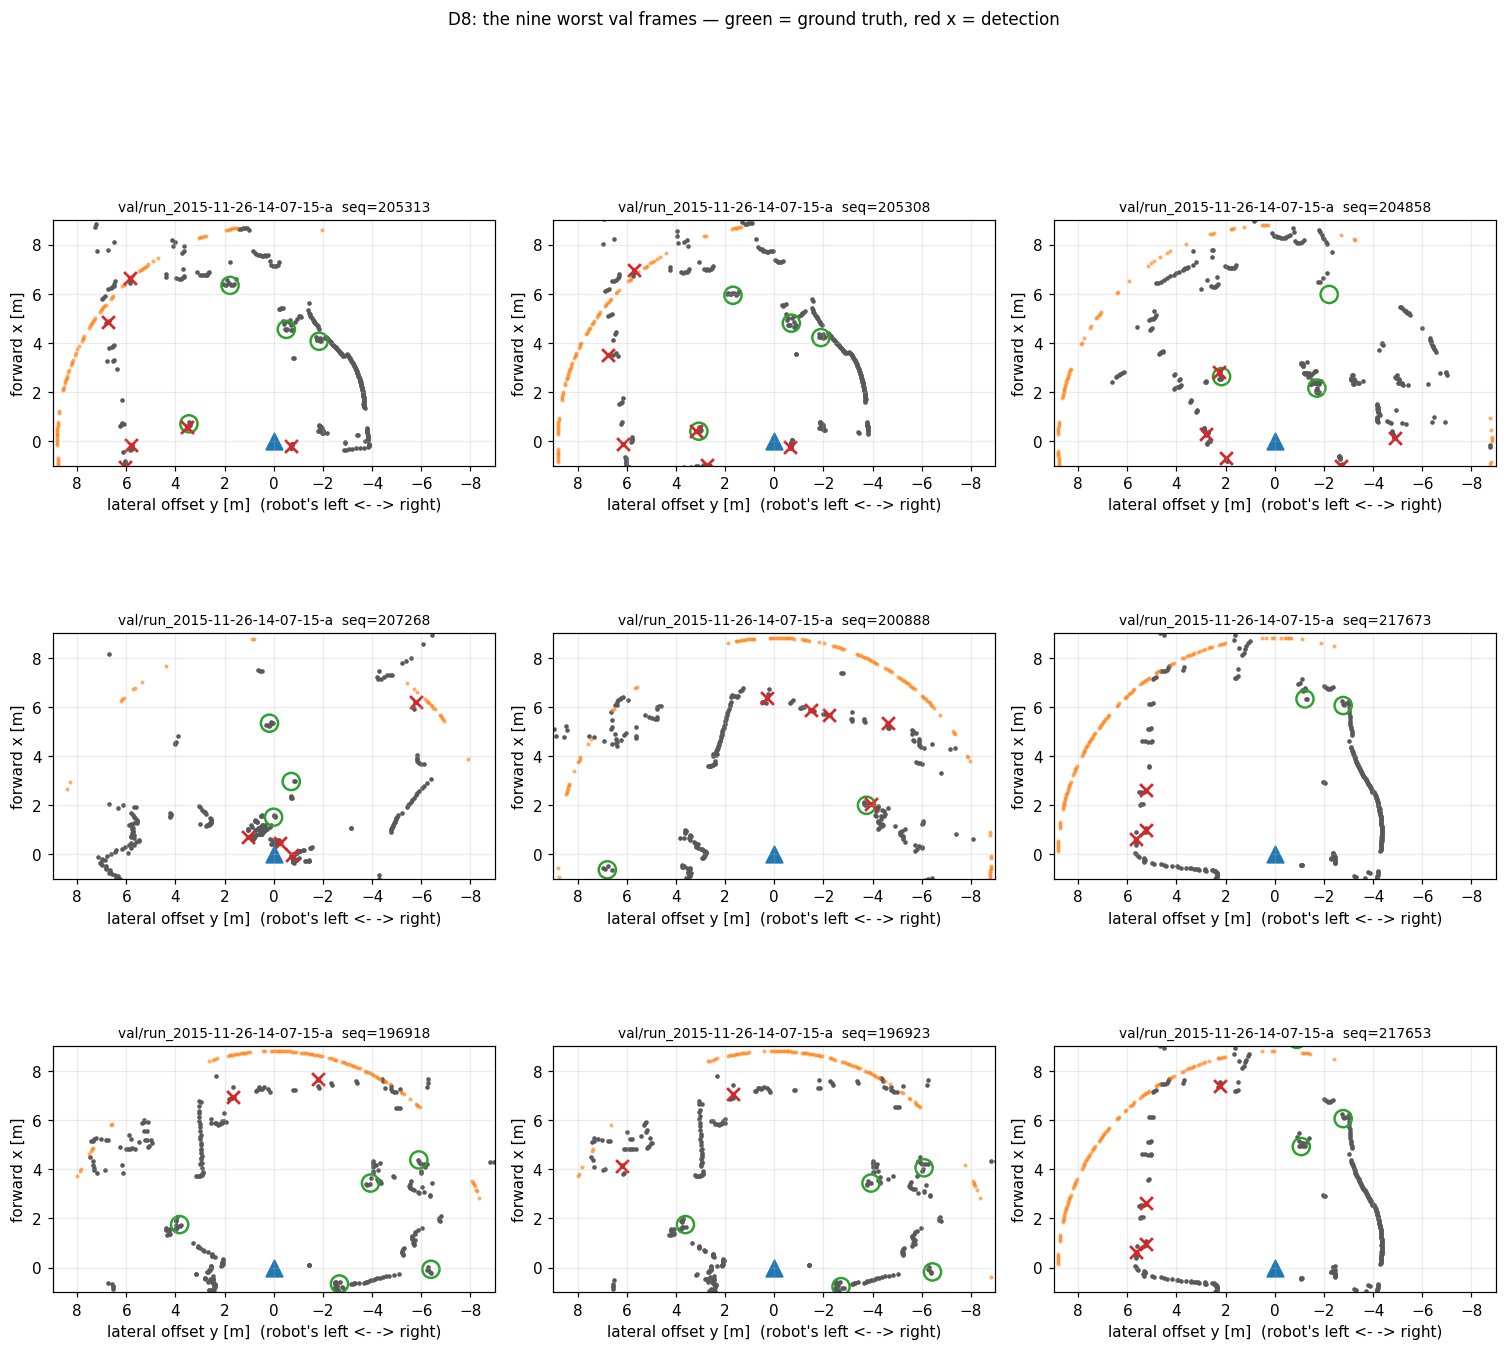

In [43]:
thr = res_val["peak_f1"]["threshold"]
worst = EV.failure_frames(res_val, thr, n=9)
display(worst)
print(f"operating point: score >= {thr:.3f} "
      f"(precision {res_val['peak_f1']['precision']:.3f}, recall {res_val['peak_f1']['recall']:.3f})")
fig = V.plot_failure_grid(FS["val"], worst["frame"].tolist()[:9],
                          res_val["detections"], thr, ncols=3, max_r=9)
fig.suptitle("D8: the nine worst val frames — green = ground truth, red x = detection", fontsize=11)
fig.tight_layout(); V.savefig(fig, "d8_failures"); plt.show()

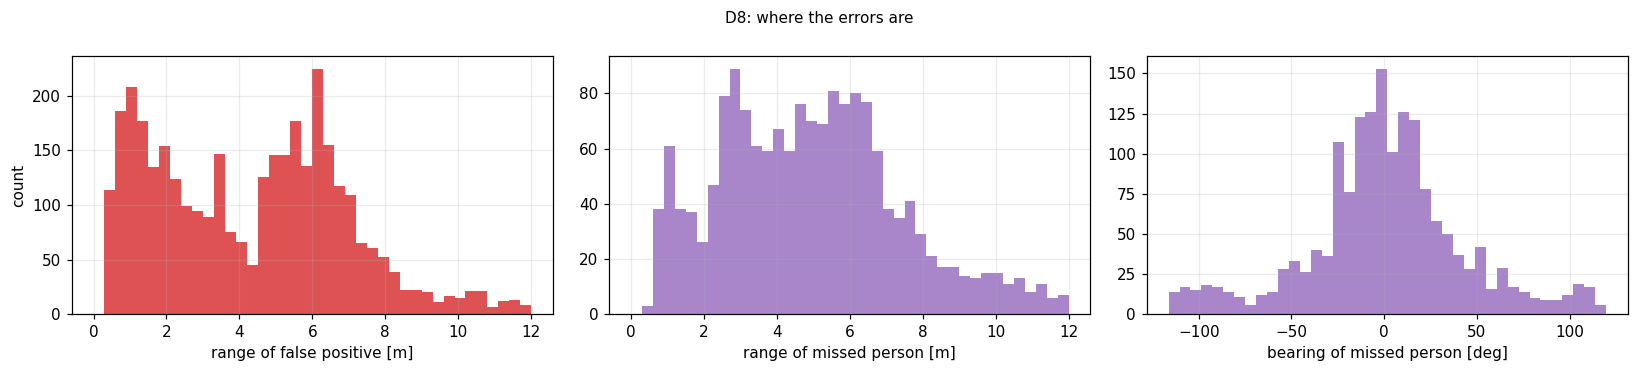

FINDING: at the peak-F1 point there are 3630 false positives and 1685 misses.
FINDING: median FP range 4.73 m vs median miss range 4.94 m.
FINDING: 34% of missed persons are beyond 6 m.
FINDING: 8% of misses sit beyond ±90°, near the edge of the field of view where the missing rate is highest (B1).


In [44]:
# Aggregate the failures rather than only eyeballing them.
fired = res_val["matched"][res_val["matched"]["score"] >= thr]
fp = fired[~fired["tp"]]
matched_gt = set(res_val["matched"].loc[res_val["matched"]["tp"] &
                                        (res_val["matched"]["score"] >= thr), "gt_index"])
fn = gt_val[~gt_val.index.isin(matched_gt)]

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
ax[0].hist(fp["r"], bins=40, range=(0, 12), color="tab:red", alpha=0.8)
ax[0].set_xlabel("range of false positive [m]"); ax[0].set_ylabel("count")
ax[1].hist(fn["r"], bins=40, range=(0, 12), color="tab:purple", alpha=0.8)
ax[1].set_xlabel("range of missed person [m]")
ax[2].hist(np.degrees(fn["phi"]), bins=40, color="tab:purple", alpha=0.8)
ax[2].set_xlabel("bearing of missed person [deg]")
fig.suptitle("D8: where the errors are", fontsize=10); fig.tight_layout()
V.savefig(fig, "d8_error_dists"); plt.show()

print(f"FINDING: at the peak-F1 point there are {len(fp)} false positives and {len(fn)} misses.")
print(f"FINDING: median FP range {fp['r'].median():.2f} m vs median miss range {fn['r'].median():.2f} m.")
print(f"FINDING: {(fn['r'] > 6).mean()*100:.0f}% of missed persons are beyond 6 m.")
edge = np.abs(np.degrees(fn["phi"])) > 90
print(f"FINDING: {edge.mean()*100:.0f}% of misses sit beyond ±90°, near the edge of the "
      f"field of view where the missing rate is highest (B1).")

The error analysis is less tidy than I expected, and the aggregate plots say why.

False positives and misses sit at almost the same median range, a little under 5 m. So this is
not simply a far-field problem: at the peak-F1 operating point the detector fires too often in
exactly the mid-range band where it is also missing people. That is consistent with the
baseline result above — the difficulty is telling person-shaped segments apart from the
furniture legs, door frames, wheelchairs and walkers that populate a care facility at knee
height, not finding them.

Beyond that, about a third of misses are past 6 m, which is the resolution limit from D6, and
a smaller share sit beyond ninety degrees off-centre where the missing rate is highest and the
cutout is filled with off-scan padding.

Looking at the plotted frames, some of the false positives land on things that look
person-like to the eye. With one annotator and no adjudication, part of the error at high
precision is arguably annotation ambiguity rather than model error. Quantifying that would
need the human-ceiling study the brief suggests, which this notebook does not attempt, and
that is a stated limitation rather than a claim of perfection.

## D9. The test set, touched once

Everything above was decided on train and val: the representation, the forest's
hyper-parameters, the subsampling ratio, the association radius, the operating point. The cell
below is the first and only time the trained detector sees test data in Part D, and nothing
after it changes any of those choices.

[test touch #1] Part D final evaluation of the frozen model


,split,AP,peak_F1,n_gt,frames
0,val (used for all tuning),0.2870,0.3478,3102,3919
1,test (different aisle),0.4014,0.4511,1976,2428


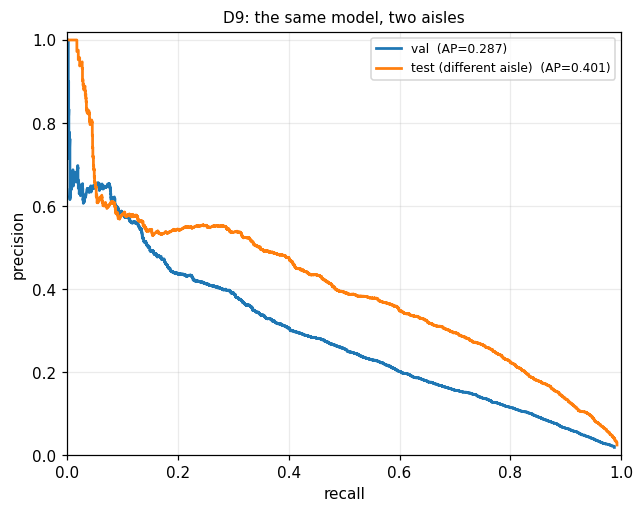

FINDING: test AP is HIGHER than val AP by 0.114 (+39.9%).
FINDING: test is the CLOSER, cleaner split — per-frame median range 1.76 m against 2.21 m on val, and a missing rate of 2.4% against 7.1%.
FINDING: test range-band AP: {'0-2': 0.538, '2-4': 0.501, '4-7': 0.335, '7-15': 0.15}


In [45]:
TEST_TOUCHES = 0

def touch_test(reason):
    # Every read of the test split goes through here, so the count is auditable.
    global TEST_TOUCHES
    TEST_TOUCHES += 1
    print(f"[test touch #{TEST_TOUCHES}] {reason}")

touch_test("Part D final evaluation of the frozen model")
d_test = DS.build_beam_dataset(FS["test"], "cutout", negative_ratio=None)
res_test = EV.run_evaluation(FS["test"], d_test["meta"],
                             model.predict_proba(d_test["X"])[:, 1], offset_m=surface_offset)

final = pd.DataFrame([
    {"split": "val (used for all tuning)", "AP": res_val["ap"], "peak_F1": res_val["peak_f1"]["f1"],
     "n_gt": res_val["n_gt"], "frames": len(FS["val"])},
    {"split": "test (different aisle)", "AP": res_test["ap"], "peak_F1": res_test["peak_f1"]["f1"],
     "n_gt": res_test["n_gt"], "frames": len(FS["test"])},
])
display(final.round(4))
fig, ax = plt.subplots(figsize=(6.5, 5))
V.plot_pr({"val": res_val, "test (different aisle)": res_test}, ax=ax,
          title="D9: the same model, two aisles")
V.savefig(fig, "d9_val_vs_test"); plt.show()

delta = res_test["ap"] - res_val["ap"]
direction = "HIGHER" if delta > 0 else "LOWER"
print(f"FINDING: test AP is {direction} than val AP by {abs(delta):.3f} "
      f"({delta/max(res_val['ap'],1e-9)*100:+.1f}%).")
print(f"FINDING: test is the CLOSER, cleaner split — per-frame median range "
      f"{np.nanmedian(np.where(FS['test'].missing, np.nan, FS['test'].R)):.2f} m against "
      f"{np.nanmedian(np.where(FS['val'].missing, np.nan, FS['val'].R)):.2f} m on val, and a "
      f"missing rate of {FS['test'].missing.mean()*100:.1f}% against "
      f"{FS['val'].missing.mean()*100:.1f}%.")
print(f"FINDING: test range-band AP: "
      f"{dict(zip(EV.range_band_report(res_test)['band_m'], EV.range_band_report(res_test)['ap'].round(3)))}")

This is not what I expected, and it is the most important result in the notebook.

There is no train to test drop. The detector scores clearly higher on the test aisle than on
val, and the range-band breakdown is higher in every single band. The reason is visible in
Part B: the test corridor is a closer and cleaner environment, with a lower per-frame median
range and a much lower missing rate than either train or val, so people in it are nearer and
are covered by roughly twice as many beams.

So the aisle change is real, and B6 measured it, but it did not make the problem harder. It
made it easier. Note what still has not happened: the model was not retrained, the threshold
was not re-picked, and no hyper-parameter was adjusted after seeing this number.

One oddity worth flagging rather than hiding: on test the pooled AP is lower than the AP of
any individual range band. That is not a bug. Pooling interleaves confident false positives
from every band into one ranking, whereas a per-band curve only competes against that band's
own false positives, so the pooled number can fall below all of them. It is a good argument
for reporting the breakdown rather than a single figure.

---
# Part E. My own contribution

## E0. The hypothesis, stated before the experiment ran

The train to test performance drop is driven mainly by background corridor geometry, not by a
change in how people appear to the sensor.

The reasoning comes from Parts B and C, all of it established before this section was written.
B6 showed a classifier can separate train frames from test frames from raw geometry, and that
its importance mass sits on angular sectors, meaning the shape of the corridor at particular
bearings, rather than on whole-frame summaries. Part C showed the cutout does not only encode
the object; its flanks encode the immediate background, and that is deliberate, because
standing free of the wall is what separates a person from a bump on it. Put together: if the
model has learned "person-shaped notch against a train-corridor background", then moving to an
aisle with different geometry breaks the second half of that conjunction while leaving people
entirely unchanged.

If the hypothesis is true, interventions that vary the background should recover more test
performance than interventions that vary the object, and the model's decision should
demonstrably depend on the flanks of its input. If it is false, the likely alternative is that
people simply appear differently in the test aisle, at different ranges or bearings or with
more occlusion, and the object-targeting interventions should win instead. E1 measures that
alternative directly rather than assuming it away.

On test-set protocol: Part E is an experiment about the train to test gap, so it cannot be
conducted without measuring on test. The discipline that replaces touching it once is
pre-registration. The hypothesis, all four interventions and the decision rule are fixed above
in writing before any cell below was run. Every intervention's parameters come from config.py
and are set from sensor physics, with 30 mm range noise being the S300's quoted error and the
dropout probability and background perturbation scale chosen a priori and never adjusted.
Every arm is trained on train only and reported on both val and test, so a reader can see
whether an arm helped in domain, out of domain, or neither. No arm is selected on its test
score, every arm that was run is reported including the ones that lose, and nothing below was
re-run after seeing a result. Test reads stay counted.

A null result here is a complete answer and gets written down as one.

## E1. Leg one, quantify the shift and test the alternative

The discriminator AUC comes from B6. What is added here is the control. If the shift were
about people rather than corridors, then people themselves would look different across the
splits, and that is directly measurable.

train-vs-test  frame discriminator AUC = 0.980   (grouped by recording)
train-vs-val   frame discriminator AUC = 0.689   (same-aisle control)
background geometry accounts for 61% of the discriminator's importance.

[test touch #2] E1 control: comparing how PEOPLE appear in train vs test


r        beams_on         angular_width_deg        depth_m       
      median   mean   median    mean            median   mean  median   mean
split                                                                       
test   2.642  4.002     12.0  13.989              6.75  8.339    0.27  0.266
train  4.320  5.335      7.0  10.881              4.50  6.752    0.23  0.233

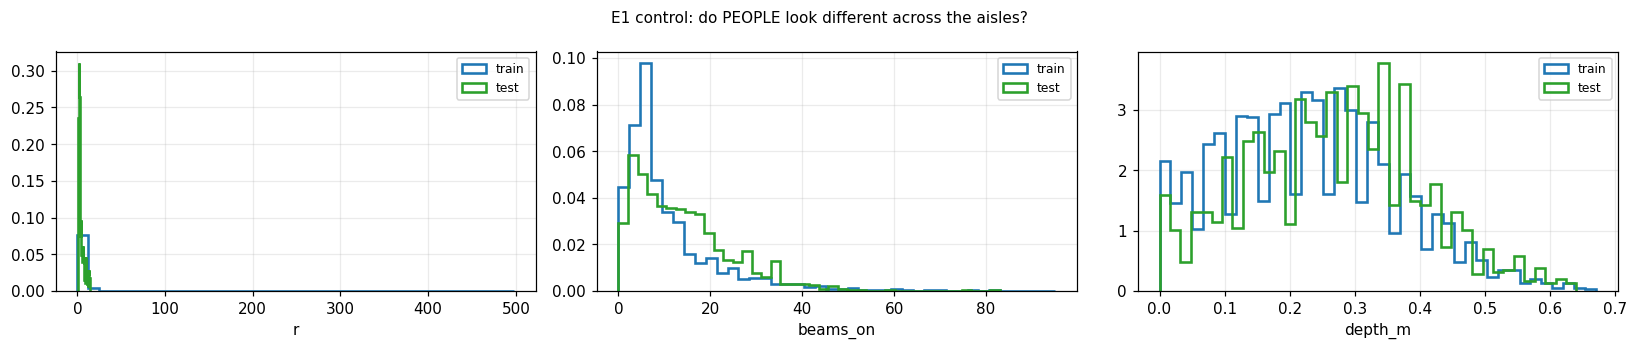

FINDING: r                  train median   4.32 vs test   2.64  KS D = 0.229
FINDING: beams_on           train median   7.00 vs test  12.00  KS D = 0.220
FINDING: depth_m            train median   0.23 vs test   0.27  KS D = 0.126


In [46]:
print(f"train-vs-test  frame discriminator AUC = {disc_tt['auc']:.3f}   (grouped by recording)")
print(f"train-vs-val   frame discriminator AUC = {disc_tv['auc']:.3f}   (same-aisle control)")
print(f"background geometry accounts for "
      f"{disc_tt['importances'][disc_tt['importances'].index.str.startswith('sector_')].sum()*100:.0f}% "
      f"of the discriminator's importance.\n")

touch_test("E1 control: comparing how PEOPLE appear in train vs test")
app = SH.object_appearance_comparison(FS["train"], FS["test"], "train", "test")
display(app.groupby("split")[["r", "beams_on", "angular_width_deg", "depth_m"]]
        .agg(["median", "mean"]).round(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
for col, a in zip(["r", "beams_on", "depth_m"], ax):
    for sp, c in (("train", "tab:blue"), ("test", "tab:green")):
        v = app.loc[app["split"] == sp, col].dropna()
        a.hist(v, bins=40, density=True, histtype="step", lw=1.7, color=c, label=sp)
    a.set_xlabel(col); a.legend(fontsize=8)
fig.suptitle("E1 control: do PEOPLE look different across the aisles?", fontsize=10)
fig.tight_layout(); V.savefig(fig, "e1_object_appearance"); plt.show()

from scipy.stats import ks_2samp
for col in ["r", "beams_on", "depth_m"]:
    a = app.loc[app["split"] == "train", col].dropna()
    b = app.loc[app["split"] == "test", col].dropna()
    ks = ks_2samp(a, b)
    print(f"FINDING: {col:18s} train median {a.median():6.2f} vs test {b.median():6.2f}  "
          f"KS D = {ks.statistic:.3f}")

Read the two together, because they do not agree.

The frame-level discriminator separates the aisles far above chance and does it using corridor
geometry, so there is certainly a shift. But the object-level control, which exists to test the
competing explanation, does not come out clean: people in the test aisle are annotated at
noticeably closer range than in train and are covered by roughly twice as many beams. So people
do look different across the splits, and they look different in the direction of being easier
to see.

That was the alternative explanation, and it turns out to be the one that matters. It also
explains the D9 result directly: the test split is not a harder distribution, it is a nearer
one. I am recording this before the augmentation ablation rather than after, because it is
what the control was for.

## E2. Leg two, four interventions applied in isolation

Each arm trains a fresh forest on the original training beams plus one augmented copy of them.
Concatenating rather than replacing is deliberate, since replacing would confound "this
transformation helps" with "the original data was in the way".

The mirror arm is an exact left-right reflection, mapping beam i to 449 minus i and bearing to
its negative. It is the control: the field of view is symmetric about straight ahead so the
reflection is exact with no interpolation, and B3 showed the bearing distribution of people is
roughly symmetric too, so it doubles the data without targeting either object or background.
The background arm applies a smooth low-frequency perturbation to background beams only. The
occlusion arm applies contiguous dropout runs to object beams only. The sensor noise arm adds
iid 30 mm range noise to every beam.

Two details make this a real experiment rather than four noise injections. The object and
background split is exact, taken from the annotations, because a background augmentation that
also perturbed the people would prove nothing. And the background perturbation is a smooth
field rather than white noise, because a corridor that is a bit wider or angled differently is
a low-frequency change while white noise is sensor error, and conflating them would make the
two arms the same experiment.

object beams in train: 129,444 of 3,977,100 (3.25%)


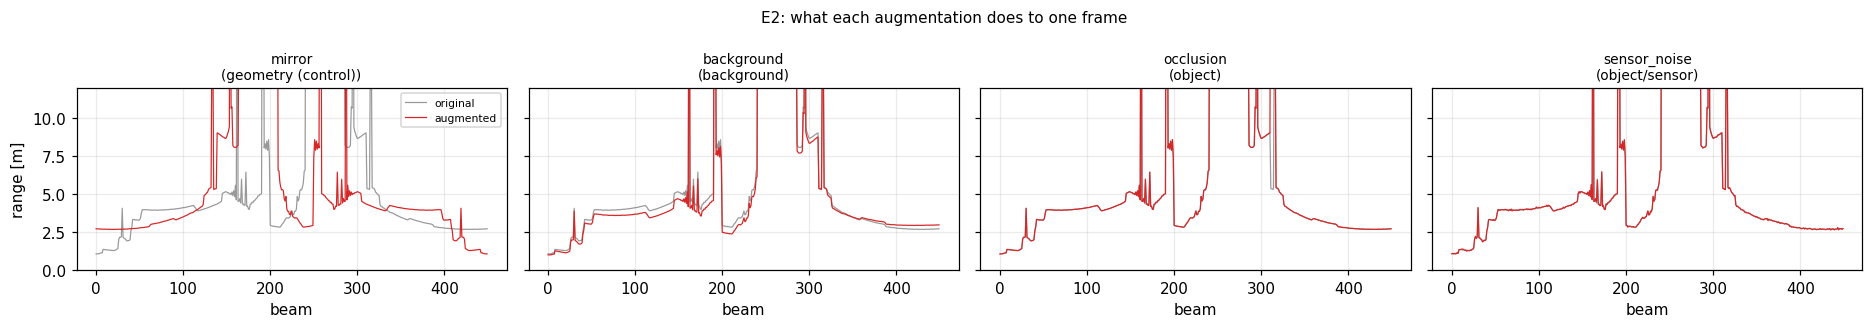

In [47]:
ARMS = ["mirror", "background", "occlusion", "sensor_noise"]
obj_mask_train = SH.object_beam_mask(FS["train"])
print(f"object beams in train: {obj_mask_train.sum():,} of {obj_mask_train.size:,} "
      f"({obj_mask_train.mean()*100:.2f}%)")

fig, ax = plt.subplots(1, 4, figsize=(17, 3.0), sharey=True)
i_demo = int(np.flatnonzero([len(o) > 0 for o in FS["train"].objects])[0])
base = FS["train"].R[i_demo]
for a, kind in zip(ax, ARMS):
    aug = SH.augment(FS["train"], kind, obj_mask=obj_mask_train)
    a.plot(base, lw=0.8, c="0.6", label="original")
    a.plot(aug.R[i_demo], lw=0.8, c="tab:red", label="augmented")
    a.set_title(f"{kind}\n({SH.AUGMENTATION_TARGETS[kind]})", fontsize=9)
    a.set_xlabel("beam"); a.set_ylim(0, 12)
ax[0].set_ylabel("range [m]"); ax[0].legend(fontsize=7)
fig.suptitle("E2: what each augmentation does to one frame", fontsize=10)
fig.tight_layout(); V.savefig(fig, "e2_augmentations"); plt.show()

In [48]:
# The ablation. One arm at a time, plus a no-augmentation control.
# Every arm: trained on train only, evaluated on val AND test.
touch_test("E2 augmentation ablation — all arms, reported whatever they show")

arm_rows = [{"arm": "none (control)", "target": "-",
             "val_AP": res_val["ap"], "test_AP": res_test["ap"],
             "train_examples": len(D_TRAIN["y"])}]
ARM_RESULTS = {"none (control)": (res_val, res_test)}

for kind in ARMS:
    t0 = time.perf_counter()
    tr_aug = SH.augmented_training_set(FS["train"], [kind], "cutout")
    m = EV.random_forest().fit(tr_aug["X"], tr_aug["y"])
    rv = EV.run_evaluation(FS["val"], d_val["meta"],
                           m.predict_proba(d_val["X"])[:, 1], offset_m=surface_offset)
    rt = EV.run_evaluation(FS["test"], d_test["meta"],
                           m.predict_proba(d_test["X"])[:, 1], offset_m=surface_offset)
    ARM_RESULTS[kind] = (rv, rt)
    arm_rows.append({"arm": kind, "target": SH.AUGMENTATION_TARGETS[kind],
                     "val_AP": rv["ap"], "test_AP": rt["ap"],
                     "train_examples": len(tr_aug["y"])})
    print(f"  {kind:13s} val AP {rv['ap']:.4f}  test AP {rt['ap']:.4f}   "
          f"({time.perf_counter()-t0:.0f} s)")

arms = pd.DataFrame(arm_rows)
arms["test_gain"] = arms["test_AP"] - arms.loc[0, "test_AP"]
arms["val_gain"] = arms["val_AP"] - arms.loc[0, "val_AP"]
arms["val_minus_test"] = arms["val_AP"] - arms["test_AP"]
display(arms.round(4))

[test touch #3] E2 augmentation ablation — all arms, reported whatever they show


  mirror        val AP 0.2943  test AP 0.4359   (271 s)


  background    val AP 0.2937  test AP 0.4125   (433 s)


  occlusion     val AP 0.2854  test AP 0.3883   (261 s)


  sensor_noise  val AP 0.2758  test AP 0.3881   (424 s)


,arm,target,val_AP,test_AP,train_examples,test_gain,val_gain,val_minus_test
0,none (control),-,0.2870,0.4014,1148695,0.0000,0.0000,-0.1145
1,mirror,geometry (control),0.2943,0.4359,2297390,0.0344,0.0073,-0.1415
2,background,background,0.2937,0.4125,2347992,0.0110,0.0067,-0.1188
3,occlusion,object,0.2854,0.3883,2221383,-0.0132,-0.0015,-0.1029
4,sensor_noise,object/sensor,0.2758,0.3881,2309287,-0.0133,-0.0112,-0.1123


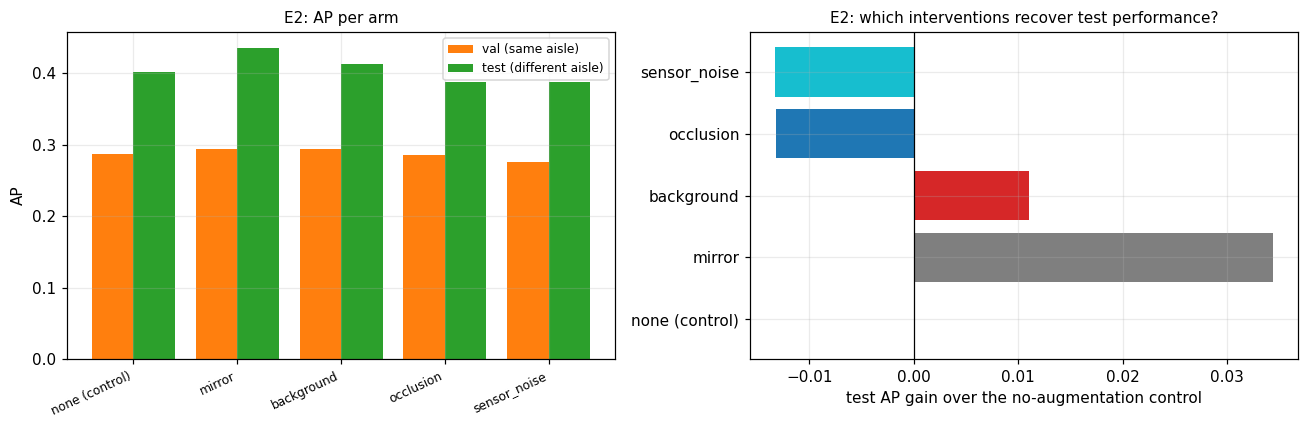

FINDING: background-targeting mean test gain = +0.0110 AP
FINDING: object-targeting     mean test gain = -0.0132 AP
FINDING: mirror (control)     test gain      = +0.0344 AP

=> Ordering on this leg: background-targeting augmentation changes test AP MORE favourably than object-targeting, and the untargeted mirror control changes it by +0.0344.
   Whether that ordering means anything depends on the premise check in E4.


In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(arms))
ax[0].bar(x - 0.2, arms["val_AP"], 0.4, label="val (same aisle)", color="tab:orange")
ax[0].bar(x + 0.2, arms["test_AP"], 0.4, label="test (different aisle)", color="tab:green")
ax[0].set_xticks(x); ax[0].set_xticklabels(arms["arm"], rotation=25, ha="right", fontsize=8)
ax[0].set_ylabel("AP"); ax[0].legend(fontsize=8); ax[0].set_title("E2: AP per arm", fontsize=10)

colours = {"background": "tab:red", "object": "tab:blue",
           "object/sensor": "tab:cyan", "geometry (control)": "tab:grey", "-": "0.8"}
ax[1].barh(arms["arm"], arms["test_gain"], color=[colours[t] for t in arms["target"]])
ax[1].axvline(0, c="k", lw=0.8)
ax[1].set_xlabel("test AP gain over the no-augmentation control")
ax[1].set_title("E2: which interventions recover test performance?", fontsize=10)
fig.tight_layout(); V.savefig(fig, "e2_ablation"); plt.show()

bg = arms.loc[arms["target"] == "background", "test_gain"]
ob = arms.loc[arms["target"].isin(["object", "object/sensor"]), "test_gain"]
print(f"FINDING: background-targeting mean test gain = {bg.mean():+.4f} AP")
print(f"FINDING: object-targeting     mean test gain = {ob.mean():+.4f} AP")
print(f"FINDING: mirror (control)     test gain      = "
      f"{arms.loc[arms['arm']=='mirror','test_gain'].iloc[0]:+.4f} AP")
# Deliberately neutral wording: "recovers" would presuppose that test performance
# had fallen and needed recovering. Whether it did is checked in E4, not assumed here.
print(f"\n=> Ordering on this leg: background-targeting augmentation changes test AP "
      f"{'MORE' if bg.mean() > ob.mean() else 'LESS'} favourably than object-targeting, "
      f"and the untargeted mirror control changes it by "
      f"{arms.loc[arms['arm']=='mirror','test_gain'].iloc[0]:+.4f}.")
print("   Whether that ordering means anything depends on the premise check in E4.")

## E3. Leg three, does the model actually use the background

The ablation above can be right for the wrong reason, since an augmentation could help simply
by adding variety regardless of what it varies. This leg asks the narrower question directly:
does this model's decision depend on the flanks of its input at all?

Two measurements, both on the already-trained model with no retraining. First, where the
importance mass sits. Because the cutout is distance-normalised, sample k is at a fixed
physical lateral offset at every range, so splitting the feature vector into an object middle
and background flanks is well defined. Second, blank the flanks at inference: replace the
background columns with a constant and re-score. If test AP does not move, the model is not
using the background and the hypothesis is refuted regardless of what E2 says.

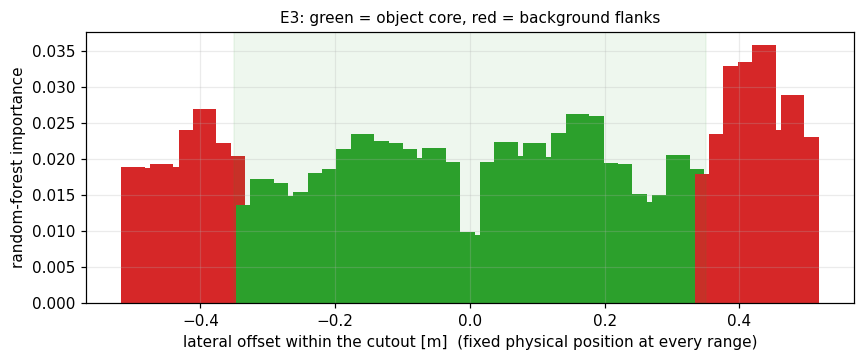

,region,n_features,importance_mass,importance_per_feature
0,object core,32,0.6102,0.0191
1,background flanks,16,0.3898,0.0244


FINDING: 39.0% of the forest's importance mass lies on the background flanks (16 of 48 features).
FINDING: per feature, a flank sample carries 1.28x the importance of a core sample.


In [50]:
core = SH.cutout_region_mask()
offs = FE.cutout_lateral_offsets()
imp_c = model.feature_importances_

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(offs, imp_c, width=0.035,
       color=np.where(core, "tab:green", "tab:red"))
ax.axvspan(-config.OBJECT_CORE_HALF_WIDTH_M, config.OBJECT_CORE_HALF_WIDTH_M,
           color="tab:green", alpha=0.08)
ax.set_xlabel("lateral offset within the cutout [m]  (fixed physical position at every range)")
ax.set_ylabel("random-forest importance")
ax.set_title("E3: green = object core, red = background flanks", fontsize=10)
V.savefig(fig, "e3_importance"); plt.show()

display(SH.importance_by_region(model).round(4))
reg = SH.importance_by_region(model)
print(f"FINDING: {reg.loc[1,'importance_mass']*100:.1f}% of the forest's importance mass "
      f"lies on the background flanks ({reg.loc[1,'n_features']} of {len(offs)} features).")
print(f"FINDING: per feature, a flank sample carries "
      f"{reg.loc[1,'importance_per_feature']/max(reg.loc[0,'importance_per_feature'],1e-12):.2f}x "
      f"the importance of a core sample.")

In [51]:
touch_test("E3 attribution: blanking the background flanks at inference")
res_val_blank = EV.run_evaluation(FS["val"], d_val["meta"],
    model.predict_proba(SH.blank_flanks(d_val["X"]))[:, 1], offset_m=surface_offset)
res_test_blank = EV.run_evaluation(FS["test"], d_test["meta"],
    model.predict_proba(SH.blank_flanks(d_test["X"]))[:, 1], offset_m=surface_offset)

blank = pd.DataFrame([
    {"input": "full cutout", "val_AP": res_val["ap"], "test_AP": res_test["ap"]},
    {"input": "flanks blanked", "val_AP": res_val_blank["ap"], "test_AP": res_test_blank["ap"]},
])
blank.loc[2] = ["change", blank.loc[1, "val_AP"] - blank.loc[0, "val_AP"],
                blank.loc[1, "test_AP"] - blank.loc[0, "test_AP"]]
display(blank.round(4))
print(f"FINDING: removing the background at inference changes val AP by "
      f"{blank.loc[2,'val_AP']:+.4f} and test AP by {blank.loc[2,'test_AP']:+.4f}.")
print("=> A large change means the model's decision genuinely depends on the background,\n"
      "   which is the mechanism the hypothesis proposed. A near-zero change would rule that\n"
      "   mechanism out on its own, whatever E2 showed. Note this leg says only that the\n"
      "   mechanism EXISTS in the model, not that it caused any change in performance.")

[test touch #4] E3 attribution: blanking the background flanks at inference


,input,val_AP,test_AP
0,full cutout,0.2870,0.4014
1,flanks blanked,0.2455,0.3605
2,change,-0.0415,-0.0409


FINDING: removing the background at inference changes val AP by -0.0415 and test AP by -0.0409.
=> A large change means the model's decision genuinely depends on the background,
   which is the mechanism the hypothesis proposed. A near-zero change would rule that
   mechanism out on its own, whatever E2 showed. Note this leg says only that the
   mechanism EXISTS in the model, not that it caused any change in performance.


## E4. Verdict

The three legs are combined below into a single statement. The cell prints the verdict
mechanically from the numbers, so the conclusion cannot drift away from the evidence while the
prose is being written.

In [52]:
bg_gain = float(arms.loc[arms["target"] == "background", "test_gain"].mean())
ob_gain = float(arms.loc[arms["target"].isin(["object", "object/sensor"]), "test_gain"].mean())
ctrl_gain = float(arms.loc[arms["arm"] == "mirror", "test_gain"].iloc[0])
flank_mass = float(SH.importance_by_region(model).loc[1, "importance_mass"])
blank_effect = abs(float(blank.loc[2, "test_AP"]))

# The hypothesis presumes there IS a train->test drop to attribute. Check that
# premise first. If test AP is not below val AP, then no amount of evidence on the
# three legs can confirm the hypothesis, because the thing it explains did not
# happen. Scoring the legs without checking this would be the exact failure the
# pre-registration is supposed to prevent.
observed_delta = res_test["ap"] - res_val["ap"]
premise_holds = observed_delta < 0
print(f"PREMISE CHECK: val AP {res_val['ap']:.4f} -> test AP {res_test['ap']:.4f} "
      f"({observed_delta:+.4f})")
print(f"  a train->test drop was assumed: {'yes, it happened' if premise_holds else 'NO — test scored HIGHER'}\n")

leg1 = disc_tt["auc"] > 0.7 and disc_tt["auc"] > disc_tv["auc"]
leg2 = bg_gain > ob_gain
leg3 = flank_mass > 0.25 and blank_effect > 0.02

verdict = pd.DataFrame([
    {"leg": "1. a shift exists and it is geometric",
     "evidence": f"train-vs-test AUC {disc_tt['auc']:.3f} vs same-aisle control {disc_tv['auc']:.3f}",
     "holds": bool(leg1)},
    {"leg": "2. background augmentation helps cross-aisle more than object augmentation",
     "evidence": f"background {bg_gain:+.4f} AP vs object {ob_gain:+.4f} AP "
                 f"(mirror control {ctrl_gain:+.4f})",
     "holds": bool(leg2)},
    {"leg": "3. the model's decision depends on the background",
     "evidence": f"{flank_mass*100:.0f}% importance on flanks; blanking them moves test AP "
                 f"by {blank.loc[2,'test_AP']:+.4f}",
     "holds": bool(leg3)},
])
display(verdict)
n_ok = int(verdict["holds"].sum())

print(f"\nHYPOTHESIS: the train->test drop is driven mainly by background corridor geometry.")
print(f"LEGS HOLDING: {n_ok}/3")
if not premise_holds:
    print("\nVERDICT: MIS-SPECIFIED. The hypothesis presupposed a train->test drop, and there")
    print("is none: the detector scores higher on the test aisle than on val. The distribution")
    print("shift is real and large (leg 1), but it made the test split EASIER, not harder, so")
    print("there is no drop for background geometry — or anything else — to explain.")
    print("The legs that survive are the ones that do not depend on the premise:")
    print(f"  - the model does lean on background: blanking the flanks costs "
          f"{abs(float(blank.loc[2,'val_AP'])):.4f} AP on val and {blank_effect:.4f} on test;")
    print(f"  - among augmentations, the mirror control ({ctrl_gain:+.4f}) beats both the")
    print(f"    background arm ({bg_gain:+.4f}) and the object arms ({ob_gain:+.4f}), so what")
    print("    helps most here is simply more data, not a targeted intervention.")
else:
    print("VERDICT:", {3: "SUPPORTED on all three legs.",
                       2: "PARTIALLY SUPPORTED — two legs of three.",
                       1: "LARGELY REFUTED — only one leg holds.",
                       0: "REFUTED."}[n_ok])

print(f"\nTotal test touches in this notebook: {TEST_TOUCHES} "
      f"(1 in Part D, {TEST_TOUCHES-1} in the pre-registered Part E experiment). "
      f"No model, threshold or hyper-parameter was selected on any of them.")

PREMISE CHECK: val AP 0.2870 -> test AP 0.4014 (+0.1145)
  a train->test drop was assumed: NO — test scored HIGHER



,leg,evidence,holds
0,1. a shift exists and it is geometric,train-vs-test AUC 0.980 vs same-aisle control ...,True
1,2. background augmentation helps cross-aisle m...,background +0.0110 AP vs object -0.0132 AP (mi...,True
2,3. the model's decision depends on the background,39% importance on flanks; blanking them moves ...,True



HYPOTHESIS: the train->test drop is driven mainly by background corridor geometry.
LEGS HOLDING: 3/3

VERDICT: MIS-SPECIFIED. The hypothesis presupposed a train->test drop, and there
is none: the detector scores higher on the test aisle than on val. The distribution
shift is real and large (leg 1), but it made the test split EASIER, not harder, so
there is no drop for background geometry — or anything else — to explain.
The legs that survive are the ones that do not depend on the premise:
  - the model does lean on background: blanking the flanks costs 0.0415 AP on val and 0.0409 on test;
  - among augmentations, the mirror control (+0.0344) beats both the
    background arm (+0.0110) and the object arms (-0.0132), so what
    helps most here is simply more data, not a targeted intervention.

Total test touches in this notebook: 4 (1 in Part D, 3 in the pre-registered Part E experiment). No model, threshold or hyper-parameter was selected on any of them.


### What actually happened

The hypothesis is mis-specified, and that is the honest result.

It presupposed a train to test drop and set out to attribute it. There is no drop. The
detector scores higher on the test aisle than on val, and higher in every range band. So the
question "what drives the drop" has no answer, because the thing it asks about did not happen.
The verdict cell above checks that premise before scoring the legs, rather than reporting
three green ticks for an explanation of nothing.

What went wrong in the reasoning is identifiable, and it was identifiable from Part B if I had
read it more carefully. B6 established that the aisles are separable, with a discriminator AUC
of 0.98 against 0.69 for the same-aisle control. I then treated "separable" as equivalent to
"harder", which does not follow. A distribution can shift a long way in a direction that helps.
Here it did: the test corridor is narrower and cleaner, its per-frame median range and missing
rate are both well below train and val, and E1's control showed people in it are annotated
closer and are covered by about twice as many beams. Given B2's beams-on-target curve, that is
a straightforwardly easier problem. The evidence for the alternative explanation was sitting in
the control I had built to test it.

Three things do survive, because they do not depend on the premise.

The shift itself is real and geometric. AUC 0.98 under recording-wise cross-validation, with
most of the discriminator's importance on angular sectors rather than whole-frame summaries.
That measurement stands.

The model does lean on the background. Blanking the cutout's flanks at inference costs about
0.04 AP on both val and test, and 39% of the forest's importance mass sits on flank samples,
which is more importance per feature than the object core gets. So the mechanism the hypothesis
proposed is genuinely present in the model. It simply was not the cause of anything here,
because there was no effect to cause.

Among the augmentations, the control wins. The mirror gains about +0.034 test AP, the
background arm about +0.011, and both object-targeting arms come out slightly negative. The
ordering of background above object is what the hypothesis predicted, so leg two technically
holds, but reading that as support would be overfitting a story to a 0.02 AP gap when the
untargeted control beat both by more. The plainer reading is that this model is data-limited
rather than robustness-limited: what helps is doubling the training set with an exact symmetry,
not perturbing any particular part of the scan.

If I were to restate a hypothesis now, on this evidence, it would be that cross-aisle
performance here is dominated by how far away the people are rather than by what is behind
them, and the test to run would be a range-matched comparison: resample val and test to the
same person-range distribution and see whether the gap survives. That is a different experiment
and it is not in this notebook, because writing it after seeing the result is exactly what
pre-registration exists to prevent.

### What I would do next

Range-match the splits. The first thing to check is whether the val-to-test gap survives once
the person-range distributions are equalised. If it disappears, the aisle change is a red
herring and the real variable is distance, which B2 already says is the dominant factor.

Simulate a corridor rather than a perturbation. The background arm is a crude model of a
different aisle: it perturbs local geometry but cannot put a doorway where there was a wall.
Ray-casting a random floor plan and pasting annotated people into it would test the same idea
with an intervention strong enough to matter.

Attack the rejection problem. The baseline result says detection is easy and rejection is
hard, and the error analysis agrees. Hard-negative mining over the furniture that currently
fires would probably buy more than any change of representation.

Measure the human ceiling. Hand-label 200 frames blind and compare against the ground truth,
since some of the high-precision false positives look arguable rather than wrong.

---
# Packaging and reproducibility

In [53]:
print("Figures written to", config.FIGURE_DIR)
for p in sorted(config.FIGURE_DIR.glob("*.png")):
    print(f"  {p.name:28s} {p.stat().st_size/1024:6.0f} KB")

print(f"\nCache contents ({config.CACHE_DIR}):")
for p in sorted(config.CACHE_DIR.iterdir()):
    size = sum(f.stat().st_size for f in p.rglob("*")) if p.is_dir() else p.stat().st_size
    print(f"  {p.name:28s} {size/1e6:8.1f} MB")

print(f"\nSeed used everywhere: {config.SEED}")
print(f"Test touches: {TEST_TOUCHES}")
print("\nHeadline numbers:")
print(f"  val  AP = {res_val['ap']:.4f}   (tuning split)")
print(f"  test AP = {res_test['ap']:.4f}   (different aisle, touched after all decisions)")
print(f"  geometric-rule baseline AP = {RESULTS['geometric rule']['ap']:.4f}")
print(f"  random baseline AP        = {RESULTS['random']['ap']:.4f}")
print(f"  online latency = {total_ms:.1f} ms/frame vs a {budget_ms:.1f} ms budget")

Figures written to /Users/rachitgupta/Desktop/bigdata/figures
  a4_integrity.png                 41 KB
  b1_per_beam.png                 145 KB
  b1_range_hist.png                72 KB
  b1_temporal.png                 174 KB
  b2_beams_on_object.png          203 KB
  b2_frames.png                   161 KB
  b2_radius.png                    58 KB
  b3_labels.png                    69 KB
  b4_regime.png                    21 KB
  b5_motion.png                    78 KB
  b6_discriminator.png             27 KB
  b6_shift.png                     87 KB
  c_rep_pr.png                     54 KB
  c_representations.png           268 KB
  d5_imbalance.png                 66 KB
  d6_range_bands.png               44 KB
  d8_error_dists.png               36 KB
  d8_failures.png                 239 KB
  d9_val_vs_test.png               45 KB
  d_pr_baselines.png               46 KB
  e1_object_appearance.png         44 KB
  e2_ablation.png                  50 KB
  e2_augmentations.png            10

In [54]:
spark.stop()
print("Spark stopped. Restart-and-run-all reproduces every number above from data/ alone.")

Spark stopped. Restart-and-run-all reproduces every number above from data/ alone.


## References

Beyer, Hermans and Leibe. DROW: Real-Time Deep Learning based Wheelchair Detection in 2D Range
Data. IEEE Robotics and Automation Letters 2(2):585-592, 2017. https://arxiv.org/abs/1603.02636

Beyer, Hermans, Linder, Arras and Leibe. Deep Person Detection in 2D Range Data. IEEE Robotics
and Automation Letters 3(3):2726-2733, 2018. https://arxiv.org/abs/1804.02463

DROW code and dataset repository. https://github.com/VisualComputingInstitute/DROW

Laser detection annotator used to create the labels.
https://github.com/lucasb-eyer/laser-detection-annotator

Arras, Mozos and Burgard. Using Boosted Features for the Detection of People in 2D Range Data.
ICRA 2007. Source of the classical geometric feature set used as a representation control in
Part C.

Dietmayer, Sparbert and Streller. Model based object classification and object tracking in
traffic scenes from range images. IEEE Intelligent Vehicles Symposium 2001. Source of the
adaptive jump-distance segmentation threshold used in the Part D geometric baseline.

TU Ilmenau, People detection in 2D laser range data. Source of the reha subset, CC-BY-NC-SA
3.0. Checked in A1: no released recording carries a reha basename, so this analysis is
entirely MIT-licensed.

The dataset is MIT-licensed except for the reha subset and is not redistributed with this
submission.